# ML Superset: Smarter Bank Campaigns

## Task 1 — Supervised Learning: Who is likely to subscribe?

### Objective

The objective is to use historical bank marketing contact records to predict
which clients are more likely to subscribe to a term deposit.

The bank has capacity to make only 500 calls. Therefore, the model will
eventually produce a ranked subscription score so that records can be
prioritised.

The prediction must use information that would be available before the
call starts.

This is a predictive analysis rather than a causal analysis. Historical
data can identify records associated with subscription, but it cannot prove
that contacting a client causes the subscription.


### Loading and Initial Inspection of the Dataset

In this step, we load the full UCI Bank Marketing dataset into Python.

* `pandas` is imported as `pd` because it is used to work with tabular data.
* `numpy` is imported as `np` for numerical operations used later in the analysis.
* `pd.read_csv()` reads the CSV file and stores it as a Pandas DataFrame called `df`.
* The dataset uses `;` as the separator between columns, so we specify `sep=";"`.
* `df.shape` tells us the number of rows and columns in the dataset.
* `df.columns` contains the column names, and `len(df.columns)` tells us how many columns there are.
* `df.head()` displays the first five records so that we can check that the data has loaded correctly and get an initial idea of the variables.

The dataset contains **41,188 historical contact records and 21 columns**. There are **20 input variables and one target variable, `y`**, which indicates whether the client subscribed to a term deposit.

At this stage, we are only loading and inspecting the data. We have not started model training yet.


In [ ]:
import pandas as pd
import numpy as np

# Load the full UCI Bank Marketing dataset.
# sep=";" is required because the CSV uses semicolons as separators.
df = pd.read_csv("bank-additional-full.csv", sep=";")

print("df shape:", df.shape)
print("df columns:", len(df.columns))
print(df.head())

df shape: (41188, 21)
df columns: 21
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  

### Dataset Shape

In this step, we check the basic dimensions of the dataset.

* `df.shape[0]` gives the number of rows, which represents the number of historical contact records.
* `df.shape[1]` gives the number of columns, which represents the number of variables.
* `df.shape` gives both values together in the form `(rows, columns)`.

Our dataset contains **41,188 historical contact records and 21 columns**.

The 21 columns consist of **20 input variables and one target variable, `y`**. The target `y` tells us whether the client subscribed to a term deposit (`yes` or `no`).

This is an initial data inspection step. We are checking the size of the dataset before moving on to understand the individual variables and their data types.


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)


Number of rows: 41188
Number of columns: 21
Dataset shape: (41188, 21)


### Initial Data Inspection

In this step, we perform a more detailed inspection of the dataset using four Pandas commands.

* `df.head()` displays the first five records so that we can see what the data looks like at the beginning.
* `df.tail()` displays the last five records and confirms that the dataset extends to the expected final row.
* `df.info()` shows the number of records, column names, data types and non-null counts.
* `df.describe()` provides statistical summaries for the numerical variables.

The dataset contains **41,188 records and 21 columns**.

The variables have different data types. Some variables are numerical, such as `age`, `campaign`, `pdays`, and `previous`. Other variables are categorical, such as `job`, `marital`, `education`, `contact`, and `poutcome`.

The `y` column is also categorical and represents the target: whether the client subscribed to a term deposit.

The `info()` output shows that the dataset does not contain actual Pandas null values. However, this does not mean that every value is meaningful. The dataset contains special values such as `unknown` and `pdays = 999`, which need to be investigated separately.

The `describe()` output also shows that `pdays` contains the value `999` very frequently. This suggests that `999` may represent a special condition rather than an ordinary number of days. We will investigate this later before deciding how to handle it.

At this stage, we are still performing exploratory data inspection. We have not trained any machine-learning model yet.


In [ ]:
print(df.head())
print(df.tail())
print(df.info())
print(df.describe())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

### Column Inventory

This step lists all columns available in the dataset so that we can understand the information available for the prediction task.

The dataset contains **21 columns**:

* Client-related variables such as `age`, `job`, `marital`, `education`, `default`, `housing`, and `loan`.
* Contact and campaign variables such as `contact`, `month`, `day_of_week`, `duration`, and `campaign`.
* Previous campaign history variables such as `pdays`, `previous`, and `poutcome`.
* Economic variables such as `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, and `nr.employed`.
* The target variable `y`.

The target `y` records whether the client subscribed to the term deposit.

At this stage, we are only identifying the available variables. We are not yet deciding which variables will be used in the final model.

Later, each input variable will be checked for **feature availability and possible data leakage**. In particular, variables containing information that would only become known during or after the call should not be used to predict whether the client will subscribe before the call.


In [ ]:
print(df.columns.tolist())


['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


### Variable Summary

To understand the structure of the dataset more systematically, we create a summary table for all variables.

The table contains four pieces of information:

* **Variable** — the name of the column.
* **Data Type** — whether the variable is numerical or categorical/text.
* **Unique Values** — the number of different values present in the column.
* **Missing Values** — the number of actual `NaN` values.

The dataset contains both numerical and categorical variables. Numerical variables include `age`, `duration`, `campaign`, `pdays`, `previous`, and the economic indicators. Categorical variables include `job`, `marital`, `education`, `contact`, `month`, `day_of_week`, and `poutcome`.

The target variable `y` has two unique values, `yes` and `no`, so it is a binary target.

The summary shows **zero actual missing (`NaN`) values in every column**. However, this does not mean that the dataset contains no missing or unknown information. Some categorical variables contain the explicit value `unknown`, which is not treated as a `NaN` value. These `unknown` categories will be investigated separately.

Understanding the data types and value structure is important because numerical and categorical variables require different preprocessing methods before machine-learning models can use them.


In [ ]:
# Create a basic variable summary

variable_summary = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Unique Values": df.nunique(),
    "Missing Values": df.isna().sum()
})

variable_summary


,Variable,Data Type,Unique Values,Missing Values
age,age,int64,78,0
job,job,object,12,0
marital,marital,object,4,0
education,education,object,8,0
default,default,object,3,0
housing,housing,object,3,0
loan,loan,object,3,0
contact,contact,object,2,0
month,month,object,10,0
day_of_week,day_of_week,object,5,0


### Missing Value Check

Before applying machine-learning models, we check whether the dataset contains actual missing values represented by `NaN`.

The following code checks every cell using `df.isna()` and then counts the missing values in each column using `.sum()`.

The result shows **zero actual `NaN` values in every column**.

However, this does not mean that there is no incomplete or unknown information in the dataset. Some categorical variables contain the explicit value `unknown`, which is treated as a normal category rather than a missing value by pandas. The variable `pdays` also contains the special value `999`, which requires separate investigation.

Therefore, we distinguish between actual `NaN` values and special or unknown values stored in the dataset.

This check is important because missing or special values can affect preprocessing and the way machine-learning models interpret the data.


In [ ]:
# Count missing values in every column

missing_values = df.isna().sum()

print(missing_values)


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


### Missing-Value Summary

This cell provides a more detailed check of missing data in the dataset.

For each variable, we calculate both the **number of actual missing (`NaN`) values** and the **percentage of values that are missing**. The missing percentage is calculated from the proportion of `NaN` values and then converted into a percentage.

The final calculation adds the missing values across all columns to determine the total number of missing cells in the dataset.

The result shows that there are **0 actual missing cells** in the dataset. Therefore, no columns require traditional missing-value imputation at this stage.

However, zero `NaN` values does not mean that the dataset contains no missing or unknown information. Some variables use explicit categories such as `unknown`, and the `pdays` variable uses the special value `999`. These cases will be investigated separately because they may represent meaningful information about previous contact history.

This cell therefore confirms that there are no technical `NaN` values while also reminding us that special missing-value codes must be handled separately.


In [ ]:
# Missing-value summary

missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

print(missing_summary)

# Total number of missing cells

print("Total missing cells:", df.isna().sum().sum())


                Missing Count  Missing Percentage
age                         0                 0.0
job                         0                 0.0
marital                     0                 0.0
education                   0                 0.0
default                     0                 0.0
housing                     0                 0.0
loan                        0                 0.0
contact                     0                 0.0
month                       0                 0.0
day_of_week                 0                 0.0
duration                    0                 0.0
campaign                    0                 0.0
pdays                       0                 0.0
previous                    0                 0.0
poutcome                    0                 0.0
emp.var.rate                0                 0.0
cons.price.idx              0                 0.0
cons.conf.idx               0                 0.0
euribor3m                   0                 0.0


### Numerical and Categorical Variables

Machine-learning models handle numerical and categorical variables differently, so we first separate the columns according to their data type.

Numerical variables are identified using `select_dtypes()` with `int64` and `float64`. These variables contain numerical values and may require operations such as imputation and scaling.

Categorical variables are identified using the `object` data type. These variables contain categories or text, such as job type, education, marital status, and contact method. They will later need to be encoded into a numerical representation before being used by the machine-learning models.

The dataset contains 10 numerical columns and 11 categorical columns, giving 21 columns in total.

The target variable `y` appears in the categorical list because it contains the values `yes` and `no`. However, `y` is the prediction target rather than an input feature, so it will later be separated from the predictor variables.

This cell only identifies variables based on their technical data type. It does not yet decide which variables are appropriate for the final model. Feature availability and possible data leakage will be considered later.


In [ ]:
# Identify numerical variables

numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical variables

categorical_cols = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical variables:")
print(numeric_cols)

print("\nCategorical variables:")
print(categorical_cols)


Numerical variables:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


### Target Distribution

The target variable `y` represents whether the client subscribed to a term deposit.

* `no` means the client did not subscribe.
* `yes` means the client subscribed.

The target distribution contains **36,548 `no` records (88.73%)** and **4,640 `yes` records (11.27%)**.

This shows that the target variable is **imbalanced**, because the two classes are not represented equally.

This imbalance is important for model evaluation. A model that always predicts the majority class (`no`) could achieve high accuracy while completely failing to identify subscribers. Therefore, accuracy alone will not be sufficient for evaluating the models.

Later in the project, additional metrics such as precision, recall, F1-score, ROC-AUC, Average Precision, Precision@500, and Lift@500 will be used.

Precision@500 and Lift@500 are particularly relevant because the bank has a limited campaign capacity of 500 calls. The final model should therefore help rank records so that the most promising records can be prioritised.


In [ ]:
target_counts = df["y"].value_counts()
print(target_counts)

target_percentages = (
    df["y"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(target_percentages)

target_summary = pd.DataFrame({
    "Count" : target_counts,
    "Percentage" : target_percentages
})

print(target_summary)

y
no     36548
yes     4640
Name: count, dtype: int64
y
no     88.73
yes    11.27
Name: proportion, dtype: float64
     Count  Percentage
y                     
no   36548       88.73
yes   4640       11.27


### Target Distribution Visualization

A bar chart is used to visually examine the distribution of the target variable `y`.

The plot shows a much larger number of records in the `no` category than in the `yes` category. This confirms the class imbalance identified in the previous numerical analysis.

There are **36,548 records where the client did not subscribe** and **4,640 records where the client subscribed**.

The visualization makes the imbalance easier to communicate and confirms that the modelling stage should not rely on accuracy alone. Metrics such as precision, recall, F1-score, ROC-AUC, Average Precision, Precision@500, and Lift@500 will be more informative for evaluating the campaign objective.


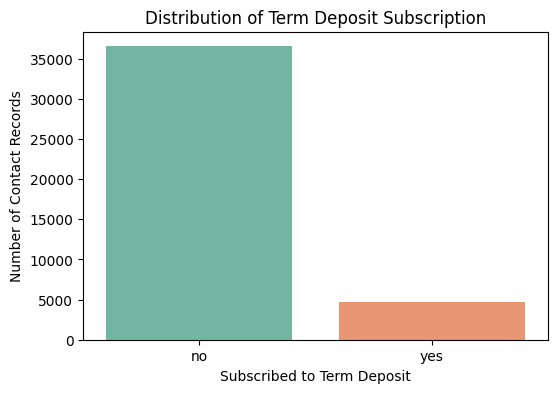

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create a figure that is 6 inches wide and 4 inches tall
plt.figure(figsize=(6, 4))

# Create a bar chart showing the number of records for each target class
sns.countplot(
    data=df,              # Use our dataset
    x="y",                # Put the target variable on the x-axis
    hue="y",              # Use target categories to colour the bars
    palette="Set2",       # Choose a colour palette
    legend=False          # No separate legend is needed
)

# Add a descriptive title
plt.title("Distribution of Term Deposit Subscription")

# Label the x-axis
plt.xlabel("Subscribed to Term Deposit")

# Label the y-axis
plt.ylabel("Number of Contact Records")

# Display the completed plot
plt.show()


### Investigation of `unknown` Values

Although the dataset contains no actual `NaN` values, some categorical variables contain the explicit value `unknown`.

Therefore, a separate check is performed to identify how many `unknown` values occur in each column and what percentage of the dataset they represent.

The code checks every column, converts the values to text, and counts values equal to `unknown`. A summary table is then created containing both the count and percentage of unknown values.

It is important to distinguish between an actual missing value (`NaN`) and an explicit `unknown` category. An `unknown` value is part of the original recorded data and may contain information about what was unavailable or not recorded.

For the modelling stage, `unknown` values will be retained as explicit categorical levels rather than automatically replacing them with the most common category. This preserves the information contained in the original dataset.


In [ ]:
# Create an empty dictionary to store unknown-value counts
unknown_counts = {}

# Check every column in the dataset
for column in df.columns:

    # Convert values to lowercase text and check which ones are "unknown"
    # .sum() counts how many True values were found
    unknown_counts[column] = (
        df[column].astype(str).str.lower() == "unknown"
    ).sum()

# Convert the dictionary into a Pandas Series
unknown_counts = pd.Series(unknown_counts)

# Create a table containing the count and percentage of unknown values
unknown_summary = pd.DataFrame({
    "Unknown Count": unknown_counts,

    # Calculate what percentage of the dataset is unknown
    "Unknown Percentage": (
        unknown_counts / len(df) * 100
    ).round(2)
})

# Show only columns that actually contain unknown values
# Sort them from the most unknown values to the least
unknown_summary[
    unknown_summary["Unknown Count"] > 0
].sort_values(
    "Unknown Count",
    ascending=False
)


,Unknown Count,Unknown Percentage
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


### Investigation of `pdays`

The `pdays` variable records the number of days since the client was previously contacted during an earlier campaign.

The frequency distribution shows that most records have the value `999`. In this dataset, `999` is a special code rather than a literal value meaning that the client was contacted 999 days ago.

A value of `999` indicates that the client was **not previously contacted in the relevant campaign history**.

There are **39,673 records with `pdays = 999`**, which represents approximately **96.32% of the 41,188 records**.

Because this value represents a special form of previous-contact history, it must be interpreted carefully during exploratory analysis and modelling. It will be retained as part of the available historical information rather than being treated as an ordinary number of days.


In [ ]:
# Show how many times each pdays value appears
# sort_index() displays the values from smallest to largest
print(df["pdays"].value_counts().sort_index())


pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64


### Further investigation of `pdays = 999`

The value `999` in `pdays` is a special code rather than an ordinary number of days.

A binary check was used to identify records where `pdays` is equal to `999`. There are **39,673 records** with this value, representing approximately **96.32% of the dataset**.

A temporary binary indicator was also created:

* `1` means `pdays = 999`
* `0` means `pdays` has another value

This investigation shows that the `pdays` variable is highly concentrated at the special value `999`. Therefore, `999` should not be interpreted as a literal number of days when analysing this variable.


In [ ]:
# Examine how often each value of pdays appears
# sort_index() arranges the pdays values from smallest to largest
print(df["pdays"].value_counts().sort_index())


# Count the number of records where pdays is equal to 999
# 999 is a special code in this dataset
pdays_999_count = (df["pdays"] == 999).sum()


# Calculate what percentage of all records have pdays = 999
pdays_999_percentage = (
    pdays_999_count / len(df) * 100
)


# Display the number of records with pdays = 999
print(
    "Number of contact records with pdays = 999:",
    pdays_999_count
)


# Display the percentage of records with pdays = 999
# round(..., 2) keeps the result to 2 decimal places
print(
    "Percentage of contact records with pdays = 999:",
    round(pdays_999_percentage, 2),
    "%"
)


# Create a temporary binary indicator:
# 1 = pdays is 999
# 0 = pdays is not 999
pdays_999 = (df["pdays"] == 999).astype(int)


# Count how many records have pdays = 999 and how many do not
print(
    pdays_999.value_counts()
)


pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64
Number of contact records with pdays = 999: 39673
Percentage of contact records with pdays = 999: 96.32 %
pdays
1    39673
0     1515
Name: count, dtype: int64


### Descriptive statistics for numerical variables

Descriptive statistics were calculated for the numerical variables to understand their distributions and ranges.

The summary includes the number of observations, mean, standard deviation, minimum, quartiles and maximum.

Several observations are useful:

* `age` has a mean of approximately 40 years.
* `duration` has a wide range, from 0 to 4,918 seconds, but it will later be excluded from the final modelling features because it is not safely available before the current call.
* `campaign` has a mean of approximately 2.57 contacts and a maximum of 56.
* `pdays` has a median of 999 because 999 is a special code representing the absence of a previous contact in the relevant campaign history.
* `previous` has a median of 0, indicating that many records have no previous campaign contacts.

These statistics help identify the scale, spread and unusual values of the numerical variables before modelling.


In [ ]:
# Descriptive statistics for numerical variables
# Shows count, mean, standard deviation, quartiles and range
# Transpose makes each numerical variable appear as a row
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


### Categorical variable frequencies

The frequency distribution of each categorical variable was examined to understand the composition of the dataset.

Several observations were identified:

* `job` contains several occupational categories, with `admin.`, `blue-collar` and `technician` being the largest groups.
* `marital` is dominated by the `married` category.
* `education` contains several education levels as well as a small `illiterate` category and an `unknown` category.
* `default` contains a large number of `unknown` values and only three records with `yes`.
* `housing` contains a relatively large number of both `yes` and `no` records, with some `unknown` values.
* `loan` is dominated by the `no` category.
* `contact` contains two categories: `cellular` and `telephone`.
* `month` is unevenly distributed, with May containing substantially more records than several other months.
* `day_of_week` is relatively balanced across the five weekdays.
* `poutcome` is dominated by the `nonexistent` category.
* `y` is the target variable and is therefore not used as a predictive input.

The dataset contains no actual `NaN` missing values, but several categorical variables contain the explicit value `unknown`. These values were investigated rather than automatically removed.


In [ ]:
# Display the categories and their frequencies for each categorical variable

for column in categorical_cols:

    # Print a separator to make the output easier to read
    print("\n" + "=" * 60)

    # Display the name of the current column
    print(column)

    # Print another separator
    print("=" * 60)

    # Count each category
    # dropna=False also shows NaN values if they exist
    print(df[column].value_counts(dropna=False))



job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
contact
ce

### Subscription rate by job

The historical subscription rate was calculated for each `job` category to investigate whether subscription outcomes differed across occupational groups.

The results show noticeable differences between groups:

* `student` had the highest historical subscription rate at approximately **31.43%**.
* `retired` records had a subscription rate of approximately **25.23%**.
* `unemployed` records had a rate of approximately **14.20%**.
* `blue-collar` records had one of the lowest rates at approximately **6.89%**.
* The `unknown` job category had a rate of approximately **11.21%**, which is close to the overall subscription rate of approximately **11.27%**.

These results suggest that `job` may contain useful information for predicting subscription outcomes.

However, this is an exploratory comparison of historical records. The differences represent associations in the data and do not establish that occupation causes a customer to subscribe.


job
student          31.43
retired          25.23
unemployed       14.20
admin.           12.97
management       11.22
unknown          11.21
technician       10.83
self-employed    10.49
housemaid        10.00
entrepreneur      8.52
services          8.14
blue-collar       6.89
Name: y, dtype: float64


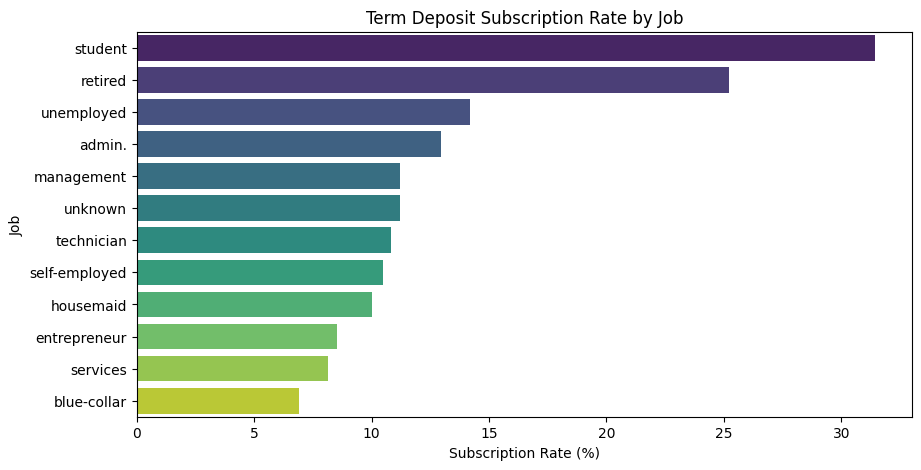

In [ ]:
# Calculate subscription rate by job

job_subscription = (
    df.groupby("job")["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .sort_values(ascending=False)
)

print(job_subscription.round(2))

plt.figure(figsize=(10, 5))

sns.barplot(
    x=job_subscription.values,
    y=job_subscription.index,
    hue=job_subscription.index,
    palette="viridis",
    legend=False
)

plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.title("Term Deposit Subscription Rate by Job")

plt.show()



### Subscription rate by contact method

The historical subscription rate was calculated for each `contact` method to investigate whether subscription outcomes differed between cellular and telephone contacts.

The results show:

* `cellular` records had a historical subscription rate of approximately **14.74%**.
* `telephone` records had a historical subscription rate of approximately **5.23%**.

The difference suggests that `contact` may contain useful predictive information.

However, these results describe an association in the historical data. They do not prove that the contact method itself causes a customer to subscribe.


contact
cellular     14.74
telephone     5.23
Name: y, dtype: float64


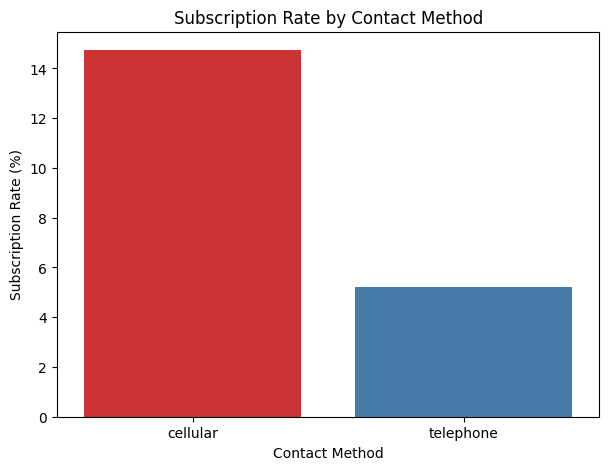

In [ ]:
# Subscription rate by contact method

contact_subscription = (
    df.groupby("contact")["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .sort_values(ascending=False)
)

print(contact_subscription.round(2))

plt.figure(figsize=(7, 5))

sns.barplot(
    x=contact_subscription.index,
    y=contact_subscription.values,
    hue=contact_subscription.index,
    palette="Set1",
    legend=False
)

plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate (%)")
plt.title("Subscription Rate by Contact Method")

plt.show()


### Subscription rate by previous campaign outcome

The historical subscription rate was examined across the `poutcome` categories to investigate whether previous campaign history was associated with the current subscription outcome.

The results show substantial differences:

* Records with a previous `success` had a historical subscription rate of approximately **65.11%**.
* Records with a previous `failure` had a rate of approximately **14.23%**.
* Records with `nonexistent` previous outcomes had a rate of approximately **8.83%**.

The much higher rate for the `success` category suggests that previous campaign history may contain useful predictive information.

However, these results represent associations in historical data and do not establish that a previous campaign outcome causes a customer to subscribe.


In [ ]:
# Relationship: Previous campaign outcome (poutcome) vs subscription (y)

# Group customers according to their previous campaign outcome,
# then calculate the proportion of "yes" and "no" subscriptions
# within each poutcome group.
poutcome_subscription = (
    df.groupby("poutcome")["y"]
      .value_counts(normalize=True)
      .unstack()
      .fillna(0)
)

# Select the "yes" subscription column and convert the proportions
# into percentages by multiplying them by 100.
poutcome_subscription["yes"] = (
    poutcome_subscription["yes"] * 100
)

# Display the subscription rate for each previous campaign outcome.
poutcome_subscription[["yes"]]

y,yes
poutcome,
failure,14.228598
nonexistent,8.832213
success,65.112891


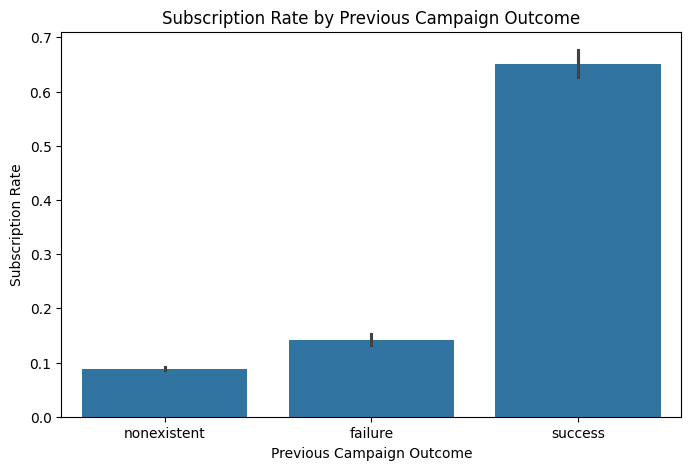

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="poutcome",
    y=df["y"].eq("yes").astype(int)
)

plt.ylabel("Subscription Rate")
plt.xlabel("Previous Campaign Outcome")
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.show()


### Subscription rate by number of campaign contacts

The `campaign` variable represents the number of contacts made during the current campaign for each record.

To make the relationship easier to interpret, the values were grouped into six categories:

* `1` contact
* `2` contacts
* `3` contacts
* `4–5` contacts
* `6–10` contacts
* `11+` contacts

The historical subscription rate was then calculated for each group.

The results show a general downward pattern:

* `1` contact → approximately **13.04%**
* `2` contacts → approximately **11.46%**
* `3` contacts → approximately **10.75%**
* `4–5` contacts → approximately **8.68%**
* `6–10` contacts → approximately **6.32%**
* `11+` contacts → approximately **3.11%**

This shows that records with more campaign contacts had lower historical subscription rates in this dataset.

However, `campaign` will **not** be used as a final modelling feature. The recorded value includes the current contact according to the dataset definition, so it is not safely available before the current call begins. Therefore, it is useful for exploratory analysis but is excluded from the final predictive model.


In [ ]:
# Relationship: Number of campaign contacts (campaign) vs subscription (y)

# Define groups for the number of contacts made during the campaign.
# Grouping the values makes the relationship easier to interpret
# than plotting every individual campaign value.
campaign_bins = [0, 1, 2, 3, 5, 10, float("inf")]

# Define readable labels for the contact groups.
campaign_labels = [
    "1",
    "2",
    "3",
    "4–5",
    "6–10",
    "11+"
]

# Create a temporary column that assigns each customer
# to one of the campaign contact groups.
df["campaign_group"] = pd.cut(
    df["campaign"],
    bins=campaign_bins,
    labels=campaign_labels
)

# Calculate the subscription rate within each campaign group.
# (y == "yes") identifies customers who subscribed.
# The mean of these True/False values gives the proportion
# of customers who subscribed, which is then multiplied by 100
# to express the result as a percentage.
campaign_subscription = (
    df.groupby("campaign_group", observed=False)["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .reset_index(name="subscription_rate")
)

# Display the subscription rate for each campaign contact group.
campaign_subscription

,campaign_group,subscription_rate
0,1,13.037071
1,2,11.456954
2,3,10.747051
3,4–5,8.682353
4,6–10,6.319555
5,11+,3.107020


### Subscription rate by number of campaign contacts — visualization

A bar chart was used to visualize the historical subscription rate across the different `campaign` contact groups.

The chart shows a general downward pattern in subscription rate as the number of campaign contacts increases. The highest rate is observed for records with one campaign contact, while the lowest rate is observed for records with 11 or more contacts.

This visualization makes the relationship identified in the numerical analysis easier to interpret.

The `campaign` variable is used here for **exploratory analysis only**. It is excluded from the final predictive features because the recorded value includes the current contact and therefore is not safely available before the current call begins.


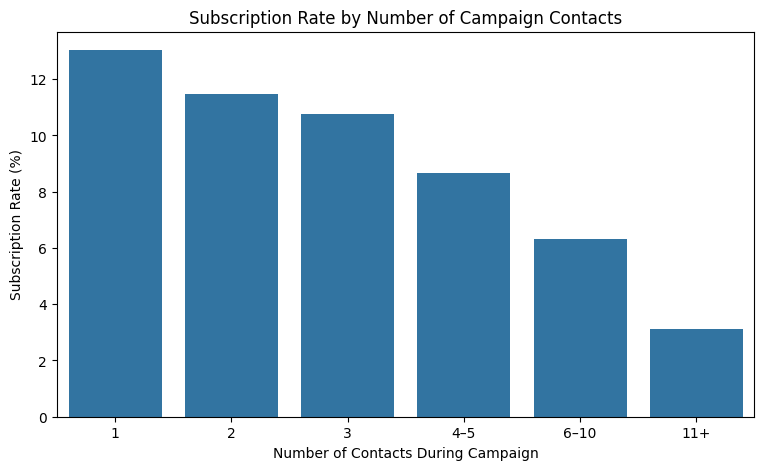

In [ ]:
# Plot the subscription rate for each campaign contact group.

plt.figure(figsize=(9, 5))

# Create a bar chart showing the subscription rate
# for each number-of-contact group.
sns.barplot(
    data=campaign_subscription,
    x="campaign_group",
    y="subscription_rate"
)

# Label the x-axis to explain what the groups represent.
plt.xlabel("Number of Contacts During Campaign")

# Label the y-axis to show that the values are percentages.
plt.ylabel("Subscription Rate (%)")

# Add a descriptive title to the chart.
plt.title("Subscription Rate by Number of Campaign Contacts")

# Display the chart.
plt.show()

### Grouping `pdays` into meaningful categories

The `pdays` variable records the number of days since a client was last contacted in a previous campaign.

Because the value `999` is a special code representing that the client was not previously contacted, it should not be interpreted as an ordinary number of days.

For exploratory analysis, `pdays` was therefore grouped into three categories:

* `0–7` days
* `8–30` days
* `999 (not previously contacted)`

The `pd.cut()` function was used to assign each record to one of these categories.

A temporary `pdays_group` column was created so that subscription rates can be compared across these groups more easily.


In [ ]:
# Define groups for the number of days since the client was previously contacted.
# The value 999 is treated separately because it represents clients
# who were not previously contacted in the relevant campaign history.

pdays_bins = [-1, 7, 30, 90, float("inf")]

# Define readable labels for the pdays groups.
pdays_labels = [
    "0–7",
    "8–30",
    "31–90",
    "91+"
]

# Create a temporary column that groups pdays values.
# Values equal to 999 will be handled separately below.
df["pdays_group"] = pd.cut(
    df["pdays"].where(df["pdays"] != 999),
    bins=pdays_bins,
    labels=pdays_labels
)

In [ ]:
# Convert the categorical column to an ordinary object column.
# This allows us to add our special 999 category.
df["pdays_group"] = df["pdays_group"].astype(object)

# Assign a separate label to customers with pdays = 999.
df.loc[
    df["pdays"] == 999,
    "pdays_group"
] = "999 (not previously contacted)"

df[["pdays", "pdays_group"]].head(10)

,pdays,pdays_group
0,999,999 (not previously contacted)
1,999,999 (not previously contacted)
2,999,999 (not previously contacted)
3,999,999 (not previously contacted)
4,999,999 (not previously contacted)
5,999,999 (not previously contacted)
6,999,999 (not previously contacted)
7,999,999 (not previously contacted)
8,999,999 (not previously contacted)
9,999,999 (not previously contacted)


### Subscription rate by `pdays` group

The historical subscription rate was calculated for each `pdays_group` to investigate whether previous-contact history was associated with the current subscription outcome.

The results show substantial differences:

* `0–7` days → approximately **65.76%**
* `8–30` days → approximately **57.10%**
* `999 (not previously contacted)` → approximately **9.26%**

The results suggest that records with previous campaign contact had much higher historical subscription rates than records with no previous contact.

This is an exploratory association in the historical data. It does not prove that previous contact causes a client to subscribe.


In [ ]:
# Calculate the subscription rate within each pdays group.
# (y == "yes") identifies customers who subscribed.
# The mean of these True/False values gives the proportion
# of customers who subscribed, which is then multiplied by 100
# to express the result as a percentage.

pdays_subscription = (
    df.groupby("pdays_group", observed=False)["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .reset_index(name="subscription_rate")
)

# Display the subscription rate for each pdays group.
pdays_subscription

,pdays_group,subscription_rate
0,0–7,65.760408
1,8–30,57.100592
2,999 (not previously contacted),9.258186


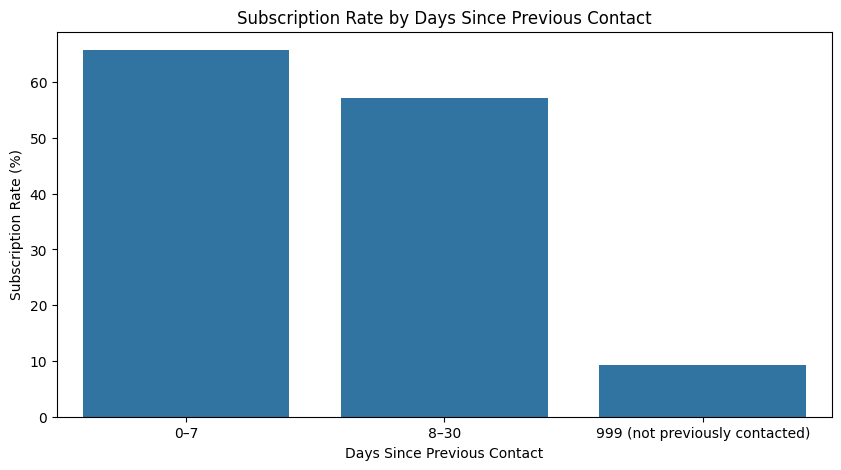

In [ ]:
# Plot the subscription rate for each pdays group.

plt.figure(figsize=(10, 5))

# Create a bar chart using the pdays groups on the x-axis
# and their subscription rates on the y-axis.
sns.barplot(
    data=pdays_subscription,
    x="pdays_group",
    y="subscription_rate"
)

# Label the x-axis.
plt.xlabel("Days Since Previous Contact")

# Label the y-axis.
plt.ylabel("Subscription Rate (%)")

# Add a descriptive title.
plt.title("Subscription Rate by Days Since Previous Contact")

# Display the chart.
plt.show()

## Feature availability and decision-point assessment

The modelling decision is made **before the current phone call starts**. Therefore, the predictive features must represent information that would be available at that decision point.

Two variables are excluded from the final modelling feature set:

* **`duration`** — this represents the duration of the current contact and is only known during or after the call. Using it before the call would introduce data leakage.
* **`campaign`** — the UCI definition includes the current contact in this variable. Therefore, the recorded value is not safely available before the current contact begins.

The remaining variables are retained because they represent client attributes, campaign-planning information, previous campaign history, or campaign-period economic indicators that are treated as available at the decision point.

This results in **18 modelling features** from the original 20 input variables.

The distinction is important: a variable can be useful for exploratory analysis but still be inappropriate for prediction if it is not available at the time the prediction must be made.


## Feature availability and decision-point assessment

The modelling decision is made **before the current phone call starts**. The UCI documentation defines `duration` as the duration of the last contact and `campaign` as the number of contacts performed during the current campaign, **including the last contact**. Because the recorded `campaign` value includes the current contact, its raw value is not safely available before that contact begins, so it is excluded from the predictive feature set.

| Input column | Available before call? | Modelling decision | Reason |
|---|---:|---:|---|
| `age`, `job`, `marital`, `education` | Yes | Include | Client attributes available before contact. |
| `default`, `housing`, `loan` | Yes | Include | Existing credit/loan information. |
| `contact`, `month`, `day_of_week` | Yes, under campaign-planning assumption | Include | These are treated as planned contact settings known before the call. |
| `duration` | No | Exclude | It is the duration of the contact and is only known during/after the call. |
| `campaign` | No, as recorded | Exclude | UCI defines it as contacts during the current campaign including the last contact, so the recorded value contains information about the current contact. |
| `pdays`, `previous`, `poutcome` | Yes | Include | Previous-campaign history is available before a new contact. |
| `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` | Yes, as campaign-period indicators | Include | Macroeconomic indicators associated with the campaign period. |

This is a predictive analysis: the historical data can identify records associated with subscription, but it does not establish that contacting a client causes the subscription.

**Dataset source:** UCI Machine Learning Repository, Bank Marketing. The UCI page states that `bank-additional-full.csv` contains 41,188 examples, 20 inputs, is ordered by date, and defines the relevant campaign/history variables.


In [ ]:
# Define the original input features that are available before the call.
# `duration` is excluded because it is post-contact.
# `campaign` is excluded because the UCI definition includes the current contact.
feature_columns = [
    "age", "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "pdays", "previous", "poutcome",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m",
    "nr.employed"
]

X = df[feature_columns].copy()
y = df["y"].copy()

print("Number of modelling features:", X.shape[1])
print("\nModelling features:")
print(X.columns.tolist())


Number of modelling features: 18

Modelling features:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


### Numerical and categorical feature groups

The 18 final modelling features were separated into numerical and categorical variables because the two types require different preprocessing methods.

There are **8 numerical features**:

* `age`
* `pdays`
* `previous`
* `emp.var.rate`
* `cons.price.idx`
* `cons.conf.idx`
* `euribor3m`
* `nr.employed`

There are **10 categorical features**:

* `job`
* `marital`
* `education`
* `default`
* `housing`
* `loan`
* `contact`
* `month`
* `day_of_week`
* `poutcome`

This separation is necessary because numerical variables can be scaled, while categorical variables need to be converted into numerical representations such as one-hot encoded features.

The two groups will therefore receive different preprocessing steps in the modelling pipeline.


In [ ]:
# Automatically identify numerical features in X
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Automatically identify categorical features in X
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Display the feature groups
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("Total number of Numerical Features : ",len(numeric_features))
print("Total number of Categorical Features : ",len(categorical_features))


Numerical features:
['age', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Total number of Numerical Features :  8
Total number of Categorical Features :  10


## Handling of `unknown` Values

The dataset contains the value `unknown` in some categorical variables. These values are treated as an explicit category rather than being automatically converted into missing values.

Keeping `unknown` as a separate category preserves the information that the value was not available or was recorded as unknown in the original dataset.

Therefore, the preprocessing pipeline will not replace `unknown` with the most frequent category. Instead, `unknown` will remain as a categorical level and will be handled by one-hot encoding.

Actual missing values (`NaN`), if present, will be handled separately by the preprocessing pipeline:

* numerical variables: median imputation
* categorical variables: most-frequent imputation


### Preprocessing pipelines

Separate preprocessing pipelines were created for numerical and categorical variables because the two types of data require different transformations.

For numerical features:

1. Any actual missing values are replaced using the median.
2. The numerical features are standardized using `StandardScaler`.

For categorical features:

1. Any actual missing values are replaced using the most frequent category.
2. The categorical variables are converted into numerical columns using one-hot encoding.

The explicit `unknown` values in the dataset are retained as valid categorical levels and are therefore not replaced by the imputation step.

Using `Pipeline` keeps these preprocessing operations together in a fixed sequence and allows the same transformations to be applied consistently to development, validation and holdout data.


In [ ]:
# Import tools for numerical preprocessing
# Import the standard Pipeline class
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Create a preprocessing pipeline for numerical features
numeric_transformer = Pipeline(
    steps=[
        (
            # Fill missing numerical values with the median
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            # Scale numerical features to a similar range
            "scaler",
            StandardScaler()
        )
    ]
)

# Create a preprocessing pipeline for categorical features
categorical_transformer = Pipeline(
    steps=[
        (
            # Fill missing categorical values with the most common category
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            # Convert categories into numerical 0/1 columns
            # Ignore categories that appear only in new data
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)


### Combining preprocessing with `ColumnTransformer`

A `ColumnTransformer` was used to combine the numerical and categorical preprocessing pipelines.

The numerical pipeline is applied only to the 8 numerical features, while the categorical pipeline is applied only to the 10 categorical features.

This allows different preprocessing methods to be applied to each data type within the same dataset:

* Numerical features → median imputation and standardization
* Categorical features → imputation and one-hot encoding

At this stage, the `ColumnTransformer` defines the preprocessing instructions. The actual transformation of the data will be performed later using the development data.


In [ ]:
# Import ColumnTransformer
from sklearn.compose import ColumnTransformer

# Apply the appropriate preprocessing to each type of feature
preprocessor = ColumnTransformer(
    transformers=[
        (
            # Numerical preprocessing
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            # Categorical preprocessing
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


### Preprocessing pipeline

The `ColumnTransformer` was placed inside a scikit-learn `Pipeline` to create one reusable preprocessing object.

The pipeline contains the complete preprocessing structure:

* numerical features are imputed and standardized;
* categorical features are imputed and one-hot encoded.

Using a pipeline keeps the preprocessing steps organized and allows the transformations to be fitted and applied consistently to the appropriate datasets during model development.


In [ ]:

preprocessing_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor)
    ]
)

print(preprocessing_pipeline)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                  

## Chronological Development / Validation / Final Holdout Split

The dataset was split chronologically because the full UCI dataset is ordered by date.

The latest **20% of records** were reserved as the final holdout set. This set is kept separate from model selection and is used only for the final evaluation and ranking.

The earlier **80% of records** were divided chronologically into:

* **Development set:** 26,360 records
* **Validation set:** 6,591 records

The final holdout contains:

* **8,237 records**

Therefore, all 41,188 records are accounted for.

The chronological approach is intended to provide a more realistic evaluation because earlier records are used to develop and compare models, while later records are reserved to represent unseen future-like observations.

The final holdout is not used to choose the final model.


## Why chronological split?

The dataset is ordered by date, so I used a chronological split rather than a random split. I reserved the latest 20% as a final holdout, then split the earlier 80% into development and validation sets. This prevents future records from influencing model development and gives a more realistic evaluation of performance on later records.

## Why is the final holdout important?

The final holdout is kept untouched during model selection. After choosing the final model using the earlier development and validation data, I evaluate it once on the holdout to estimate how it performs on unseen later records.

In [ ]:
# ============================================================
# Chronological Development / Validation / Final Holdout Split
# ============================================================

# Step 1: Reserve the latest 20% as the final holdout
holdout_size = int(len(X) * 0.20)

X_train = X.iloc[:-holdout_size].copy()
X_holdout = X.iloc[-holdout_size:].copy()

y_train = y.iloc[:-holdout_size].copy()
y_holdout = y.iloc[-holdout_size:].copy()

# Step 2: Split the earlier 80% chronologically into
# Development (80%) and Validation (20%)
development_size = int(len(X_train) * 0.80)

X_development = X_train.iloc[:development_size].copy()
X_validation = X_train.iloc[development_size:].copy()

y_development = y_train.iloc[:development_size].copy()
y_validation = y_train.iloc[development_size:].copy()

print("Development set:", X_development.shape)
print("Validation set:", X_validation.shape)
print("Final holdout:", X_holdout.shape)

Development set: (26360, 18)
Validation set: (6591, 18)
Final holdout: (8237, 18)


### Fitting and applying the preprocessing

The preprocessing was fitted **only on the Development set**.

The `fit_transform()` operation learns the preprocessing parameters from the Development data and transforms that same data.

The Validation and Final Holdout sets are transformed using `transform()` only. They are not used to fit the preprocessing.

This prevents information from the Validation or Final Holdout sets from influencing the preprocessing stage.

The original dataset contains **18 modelling features**, while the transformed data contains **57 features**. The increase occurs mainly because categorical variables are expanded into multiple one-hot encoded columns.

All three datasets have the same transformed feature structure so that the trained models can be evaluated consistently.


In [ ]:
# Fit preprocessing only on Development data
X_development_transformed = preprocessor.fit_transform(X_development)

# Apply the already-fitted preprocessing to Validation
X_validation_transformed = preprocessor.transform(X_validation)

# Apply the already-fitted preprocessing to Final Holdout
X_holdout_transformed = preprocessor.transform(X_holdout)

print("Development transformed shape:", X_development_transformed.shape)
print("Validation transformed shape:", X_validation_transformed.shape)
print("Holdout transformed shape:", X_holdout_transformed.shape)

Development transformed shape: (26360, 57)
Validation transformed shape: (6591, 57)
Holdout transformed shape: (8237, 57)


### Checking the data split

A simple consistency check was performed to confirm that all records from the original dataset were included in one of the three chronological splits.

The dataset contains **41,188 records** in total.

The split contains:

* **Development:** 26,360 records
* **Validation:** 6,591 records
* **Final Holdout:** 8,237 records

The three sets together contain **41,188 records**, which matches the original dataset size.

This confirms that the chronological split accounted for all records.




In [ ]:
print("Total rows:", len(X))
print("Development:", len(X_development))
print("Validation:", len(X_validation))
print("Holdout:", len(X_holdout))

print("Sum of splits:",
      len(X_development) + len(X_validation) + len(X_holdout))

Total rows: 41188
Development: 26360
Validation: 6591
Holdout: 8237
Sum of splits: 41188


### Checking the transformed feature structure

A dimensionality check was performed after preprocessing to confirm that the transformed datasets have the expected structure.

The original modelling data contains **18 features**.

After preprocessing, the data contains **57 features**. The increase is mainly due to one-hot encoding of categorical variables, which converts each category into separate numerical columns.

The transformed datasets contain:

* **Development:** 26,360 rows and 57 features
* **Validation:** 6,591 rows and 57 features
* **Final Holdout:** 8,237 rows and 57 features

The three datasets therefore have the same transformed feature structure, which is required for consistent model training and evaluation.


In [ ]:
# Check that the preprocessing produced the expected number of features.
print("\nOriginal training features:", X_train.shape[1])
print("Transformed development features:", X_development_transformed.shape[1])

# Check that the transformed datasets have the same feature structure.
print("Transformed development rows:", X_development_transformed.shape[0])
print("Transformed validation rows:", X_validation_transformed.shape[0])
print("Transformed holdout rows:", X_holdout_transformed.shape[0])



Original training features: 18
Transformed development features: 57
Transformed development rows: 26360
Transformed validation rows: 6591
Transformed holdout rows: 8237


### Converting the target to binary labels

The target variable `y` originally contains two categorical values:

* `no` → the client did not subscribe
* `yes` → the client subscribed

For modelling, these values were converted into binary numerical labels:

* **0** → did not subscribe
* **1** → subscribed

The training and final holdout target distributions were then checked separately.

The training data contains:

* **30,851 non-subscribers**
* **2,100 subscribers**

The final holdout contains:

* **5,697 non-subscribers**
* **2,540 subscribers**

The target is therefore imbalanced. Because of this imbalance, accuracy alone will not be sufficient for evaluating model performance. Metrics such as precision, recall, F1-score, ROC-AUC and Average Precision will also be considered.


In [ ]:
# Convert the target variable from "no"/"yes" to 0/1.
# 1 = client subscribed
# 0 = client did not subscribe

y_train_binary = (y_train == "yes").astype(int)
y_holdout_binary = (y_holdout == "yes").astype(int)

print("Training target distribution:")
print(y_train_binary.value_counts())

print("\nHoldout target distribution:")
print(y_holdout_binary.value_counts())

Training target distribution:
y
0    30851
1     2100
Name: count, dtype: int64

Holdout target distribution:
y
0    5697
1    2540
Name: count, dtype: int64


### Majority-class baseline

A simple **majority-class baseline** was created using `DummyClassifier`.

The baseline uses the `most_frequent` strategy, which always predicts the class that appears most often in the training data.

In this dataset, the majority class is:

* `0` → did not subscribe

Therefore, the baseline predicts **0 for every holdout record**.

This model does not use meaningful relationships between the input features and the target. Instead, it provides a simple reference point against which the more advanced models can be compared.

The purpose of the baseline is to determine whether the predictive models provide useful improvement over simply predicting the majority class for every record.


In [ ]:
# Import DummyClassifier to create a simple baseline model.
from sklearn.dummy import DummyClassifier


# Create a majority-class baseline.
# "most_frequent" means the model always predicts
# whichever target class is most common in the training data.
majority_baseline = DummyClassifier(
    strategy="most_frequent"
)


# Fit the baseline using the training data only.
# The model uses y_train_binary to determine
# which class is the majority class.
majority_baseline.fit(
    X_train,
    y_train_binary
)


# Generate class predictions for the final holdout data.
# Because this is a majority-class baseline,
# the same class will be predicted for every holdout observation.
majority_predictions = majority_baseline.predict(
    X_holdout
)


# Generate predicted probabilities for the final holdout data.
# Each customer receives the same class probabilities
# because the baseline does not use customer-specific features.
majority_probabilities = majority_baseline.predict_proba(
    X_holdout
)


# Display the first few predictions.
print("First 10 predictions:")
print(majority_predictions[:10])


# Display the first few predicted probabilities.
print("\nFirst 10 predicted probabilities:")
print(majority_probabilities[:10])

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


### Majority baseline evaluation

The majority-class baseline was evaluated on the final holdout data using a confusion matrix, precision, recall and F1-score.

Because the baseline predicts **0 for every record**, it does not identify any of the actual subscribers.

As a result:

* **Precision = 0**
* **Recall = 0**
* **F1-score = 0**

The baseline therefore provides little value for the campaign objective.

This result also demonstrates why accuracy alone is not an appropriate measure for this problem. The target is imbalanced, so a model could obtain many correct predictions by mainly predicting the majority class while failing to identify subscribers.

The more advanced models must therefore be evaluated using metrics that measure their ability to identify the positive class and rank likely subscribers.


In [ ]:
# Import evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)


# Calculate the confusion matrix.
# It compares the actual holdout outcomes with
# the predictions made by the majority baseline.
baseline_cm = confusion_matrix(
    y_holdout_binary,
    majority_predictions
)


# Calculate precision.
# This measures how many predicted YES cases
# were actually YES.
baseline_precision = precision_score(
    y_holdout_binary,
    majority_predictions,
    zero_division=0
)


# Calculate recall.
# This measures how many actual YES cases
# were successfully identified.
baseline_recall = recall_score(
    y_holdout_binary,
    majority_predictions,
    zero_division=0
)


# Calculate F1-score.
# F1 combines precision and recall into one measure.
baseline_f1 = f1_score(
    y_holdout_binary,
    majority_predictions,
    zero_division=0
)


# Display the results.
print("Majority Baseline Results")
print("--------------------------")

print("\nConfusion Matrix:")
print(baseline_cm)

print("\nPrecision:", round(baseline_precision, 4))
print("Recall:", round(baseline_recall, 4))
print("F1-score:", round(baseline_f1, 4))

Majority Baseline Results
--------------------------

Confusion Matrix:
[[5697    0]
 [2540    0]]

Precision: 0.0
Recall: 0.0
F1-score: 0.0


### Logistic Regression model

Logistic Regression was used as the first predictive classification model.

The model predicts the binary target:

* **0** → did not subscribe
* **1** → subscribed

The Logistic Regression classifier was placed inside a scikit-learn `Pipeline` together with the preprocessing step. This means that the input data is preprocessed before being passed to the classifier.

The model was fitted using the training data and corresponding binary target values.

`max_iter=2000` gives the optimisation process enough iterations to reach convergence, while `random_state=42` helps make the results reproducible.

Logistic Regression provides a simple and interpretable machine-learning benchmark against which the more complex models can later be compared.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]
)
logistic_model.fit(
    X_train,
    y_train_binary
)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

### Logistic Regression predictions

The trained Logistic Regression model was used to generate predictions for the final holdout data.

Two outputs were generated:

* **Predicted classes:** `0` for predicted non-subscription and `1` for predicted subscription.
* **Predicted probabilities:** the estimated probability that each record belongs to the subscription class (`1`).

The subscription probabilities are especially important because the campaign objective is not simply to classify records as yes or no. The bank has a limited capacity of **500 calls**, so records can later be ranked according to their predicted subscription probability.

A record with a higher predicted probability is considered more promising for the campaign ranking than a record with a lower predicted probability.


In [ ]:
logistic_predictions = logistic_model.predict(
    X_holdout
)

logistic_probabilities = logistic_model.predict_proba(
    X_holdout
)[:, 1]

print("First 10 predicted classes:")
print(logistic_predictions[:10])

print("\nFirst 10 predicted probabilities:")
print(logistic_probabilities[:10])

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.04912256 0.03669471 0.07502354 0.035372   0.07215528 0.03433296
 0.0672707  0.08281264 0.07726694 0.0326887 ]


### Logistic Regression evaluation

The Logistic Regression model was evaluated on the final holdout data using several classification and probability-based metrics.

The confusion matrix was:

* **True Negatives:** 5,095
* **False Positives:** 602
* **False Negatives:** 1,670
* **True Positives:** 870

The resulting metrics were:

* **Accuracy:** 0.7242
* **Precision:** 0.5910
* **Recall:** 0.3425
* **F1-score:** 0.4337
* **ROC-AUC:** 0.7476
* **Average Precision:** 0.5249

The results show that Logistic Regression provides useful predictive discrimination compared with the majority-class baseline.

Accuracy is not considered sufficient on its own because the target is imbalanced. Precision, recall and F1-score provide information about the positive subscription class, while ROC-AUC and Average Precision evaluate the quality of the predicted probabilities across different thresholds.

The model is not selected as the final model at this stage. It is treated as one candidate for comparison with other modelling approaches.
"

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# --------------------------------------------------
# 1. Confusion Matrix
# --------------------------------------------------

logistic_cm = confusion_matrix(
    y_holdout_binary,
    logistic_predictions
)

print("Logistic Regression Confusion Matrix:")
print(logistic_cm)


# --------------------------------------------------
# 2. Classification Metrics
# --------------------------------------------------

logistic_accuracy = accuracy_score(
    y_holdout_binary,
    logistic_predictions
)

logistic_precision = precision_score(
    y_holdout_binary,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_holdout_binary,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_holdout_binary,
    logistic_predictions,
    zero_division=0
)


# --------------------------------------------------
# 3. Probability-based Metrics
# --------------------------------------------------

logistic_roc_auc = roc_auc_score(
    y_holdout_binary,
    logistic_probabilities
)

logistic_average_precision = average_precision_score(
    y_holdout_binary,
    logistic_probabilities
)


# --------------------------------------------------
# 4. Display Results
# --------------------------------------------------

print("\nLogistic Regression Evaluation")
print("--------------------------------")
print(f"Accuracy:            {logistic_accuracy:.4f}")
print(f"Precision:           {logistic_precision:.4f}")
print(f"Recall:              {logistic_recall:.4f}")
print(f"F1-score:            {logistic_f1:.4f}")
print(f"ROC-AUC:             {logistic_roc_auc:.4f}")
print(f"Average Precision:   {logistic_average_precision:.4f}")

Logistic Regression Confusion Matrix:
[[5095  602]
 [1670  870]]

Logistic Regression Evaluation
--------------------------------
Accuracy:            0.7242
Precision:           0.5910
Recall:              0.3425
F1-score:            0.4337
ROC-AUC:             0.7476
Average Precision:   0.5249


### Random Forest model

Random Forest was used as the second predictive model and as the required **bagging/tree ensemble** method.

A Random Forest combines the predictions of many decision trees rather than relying on a single tree. This allows the model to capture nonlinear relationships and interactions between features.

The model was configured with:

* `n_estimators=300` → 300 decision trees
* `min_samples_leaf=5` → each leaf must contain at least 5 training observations
* `random_state=42` → improves reproducibility
* `n_jobs=-1` → uses available CPU cores to speed up training

The Random Forest was placed inside a Pipeline with the preprocessing step so that preprocessing and model training remain part of the same workflow.

The model was fitted using the training data and binary subscription target.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)
random_forest_model.fit(
    X_train,
    y_train_binary
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('classifier',
                 RandomForestClassifier(min_samples_leaf=5, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

### Random Forest predictions

The trained Random Forest model was used to generate predictions for the final holdout data.

Two types of predictions were generated:

* **Predicted classes:** `0` indicates predicted non-subscription and `1` indicates predicted subscription.
* **Predicted probabilities:** the estimated probability that each record belongs to the subscription class (`1`).

The subscription probabilities are particularly important because the campaign has a limited call capacity of **500 records**. These probabilities can later be used to rank the holdout records from highest to lowest predicted subscription likelihood.

The first ten class predictions were all `0`, but their predicted probabilities were different. This shows why probability scores are more useful than only binary predictions for the final campaign-ranking task.


In [ ]:
random_forest_predictions = random_forest_model.predict(
    X_holdout
)

random_forest_probabilities = random_forest_model.predict_proba(
    X_holdout
)[:, 1]

print("First 10 predicted classes:")
print(random_forest_predictions[:10])

print("\nFirst 10 predicted probabilities:")
print(random_forest_probabilities[:10])

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.15341129 0.09335622 0.06630759 0.07072881 0.05655713 0.07750458
 0.12759663 0.09399221 0.093693   0.02443365]


### Random Forest evaluation

The Random Forest model was evaluated on the final holdout data using a confusion matrix, classification metrics and probability-based metrics.

The confusion matrix was:

* **True Negatives:** 5,697
* **False Positives:** 0
* **False Negatives:** 2,540
* **True Positives:** 0

The resulting metrics were:

* **Accuracy:** 0.6916
* **Precision:** 0.0000
* **Recall:** 0.0000
* **F1-score:** 0.0000
* **ROC-AUC:** 0.7394
* **Average Precision:** 0.5335

The zero precision, recall and F1-score occurred because the Random Forest did not predict any records as class `1` using its default classification threshold.

However, the probability-based metrics were not zero. The model produced different subscription probability scores for different records, giving it some ability to distinguish between more and less promising records.

This distinction is important for the campaign objective. The bank has a limited call capacity of 500 records, so the final decision can be based on ranking records by predicted subscription probability rather than relying only on a fixed classification threshold.

Therefore, Random Forest is retained as a candidate model for further comparison, but it is not selected as the final model at this stage.


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# --------------------------------------------------
# 1. Confusion Matrix
# --------------------------------------------------

random_forest_cm = confusion_matrix(
    y_holdout_binary,
    random_forest_predictions
)

print("Random Forest Confusion Matrix:")
print(random_forest_cm)


# --------------------------------------------------
# 2. Classification Metrics
# --------------------------------------------------

random_forest_accuracy = accuracy_score(
    y_holdout_binary,
    random_forest_predictions
)

random_forest_precision = precision_score(
    y_holdout_binary,
    random_forest_predictions,
    zero_division=0
)

random_forest_recall = recall_score(
    y_holdout_binary,
    random_forest_predictions,
    zero_division=0
)

random_forest_f1 = f1_score(
    y_holdout_binary,
    random_forest_predictions,
    zero_division=0
)


# --------------------------------------------------
# 3. Probability-Based Metrics
# --------------------------------------------------

random_forest_roc_auc = roc_auc_score(
    y_holdout_binary,
    random_forest_probabilities
)

random_forest_average_precision = average_precision_score(
    y_holdout_binary,
    random_forest_probabilities
)


# --------------------------------------------------
# 4. Display Results
# --------------------------------------------------

print("\nRandom Forest Evaluation")
print("--------------------------------")
print(f"Accuracy:            {random_forest_accuracy:.4f}")
print(f"Precision:           {random_forest_precision:.4f}")
print(f"Recall:              {random_forest_recall:.4f}")
print(f"F1-score:            {random_forest_f1:.4f}")
print(f"ROC-AUC:             {random_forest_roc_auc:.4f}")

print(f"Average Precision:   {random_forest_average_precision:.4f}")

Random Forest Confusion Matrix:
[[5697    0]
 [2540    0]]

Random Forest Evaluation
--------------------------------
Accuracy:            0.6916
Precision:           0.0000
Recall:              0.0000
F1-score:            0.0000
ROC-AUC:             0.7394
Average Precision:   0.5335


### Boosting-specific preprocessing

A separate preprocessing setup was created for the `HistGradientBoostingClassifier`.

The numerical features use the existing numerical preprocessing pipeline:

* actual missing values are replaced using the median;
* numerical values are standardized using `StandardScaler`.

The categorical features use a categorical pipeline that:

* replaces actual missing values using the most frequent category;
* applies one-hot encoding;
* produces a **dense numerical matrix** using `sparse_output=False`.

The dense output is required for the HistGradientBoosting model used in this project.

The explicit `unknown` category in the original dataset remains a valid categorical value and is not automatically treated as a missing value.

At this stage, no model has been trained. This cell only defines the preprocessing instructions that will be used by the boosting model.


In [ ]:
boosting_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)
boosting_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", boosting_categorical_transformer, categorical_features)
    ]
)

### HistGradientBoosting model

`HistGradientBoostingClassifier` was used as the required **boosting** method.

Boosting builds a sequence of tree-based models, where later stages try to improve the predictions made by the earlier stages.

The model was configured with:

* `max_iter=200` → allows up to 200 boosting iterations.
* `learning_rate=0.05` → controls the contribution of each boosting stage.
* `max_leaf_nodes=15` → limits the complexity of each individual tree.
* `l2_regularization=1.0` → adds regularization to help control model complexity.
* `random_state=42` → makes the modelling process reproducible.

The boosting-specific preprocessing was placed inside the same `Pipeline` as the classifier. Therefore, the raw input data is first transformed and then passed to the boosting model.

The model was fitted using the training data and binary subscription target.

This model is included because the assignment requires a boosting approach in addition to the Logistic Regression and Random Forest models.


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

boosting_model = Pipeline(
    steps=[
        ("preprocessor", boosting_preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42
        ))
    ]
)

boosting_model.fit(
    X_train,
    y_train_binary
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('classifier',
                 HistGradientBoostingClassifier(l2_regularization=1.0,
                                                learning_rate=0.05,
                                                max_iter=200, max_leaf_nodes=15,
                                                random_state=42))])

### HistGradientBoosting predictions

The trained HistGradientBoosting model was used to generate predictions for the final holdout data.

Two types of predictions were produced:

* **Predicted classes:** `0` indicates predicted non-subscription and `1` indicates predicted subscription.
* **Predicted probabilities:** the estimated probability that each record belongs to the subscription class (`1`).

The subscription probability was extracted using `[:, 1]` from `predict_proba()`.

The probability scores are particularly important for this project because the bank has a limited capacity of **500 calls**. The records can therefore be ranked from highest to lowest predicted subscription probability, allowing the most promising records to be prioritised.

The model's binary predictions and probability scores serve different purposes: the classes are useful for threshold-based classification metrics, while the probabilities are important for ranking and campaign-budget evaluation.


In [ ]:
boosting_predictions = boosting_model.predict(X_holdout)

boosting_probabilities = boosting_model.predict_proba(X_holdout)[:, 1]

print("First 10 predicted classes:")
print(boosting_predictions[:10])

print("\nFirst 10 predicted probabilities:")
print(boosting_probabilities[:10])

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.12596197 0.03768609 0.08766247 0.05055055 0.04815242 0.03589904
 0.07832979 0.07538194 0.07587846 0.0248641 ]


### HistGradientBoosting evaluation

The HistGradientBoosting model was evaluated on the final holdout data using the same metrics used for the other candidate models.

The evaluation included:

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
* Average Precision

The early holdout diagnostic results were approximately:

* **Accuracy:** 0.6904
* **Precision:** 0.4737
* **Recall:** 0.0354
* **F1-score:** 0.0659
* **ROC-AUC:** 0.6200
* **Average Precision:** 0.4128

The relatively low recall indicates that the model identified only a small proportion of the actual subscribers using its default classification threshold.

However, these results are treated as an **early holdout diagnostic only**. The final model is not selected using these holdout results. Official model comparison is performed later on the chronological validation period using the campaign objective, including **Precision@500**.

This distinction is important because the business problem is primarily a ranking problem: the bank has capacity to make only 500 calls and therefore needs to prioritise the records with the highest predicted subscription probability.


In [ ]:
boosting_confusion_matrix = confusion_matrix(
    y_holdout_binary,
    boosting_predictions
)

boosting_accuracy = accuracy_score(
    y_holdout_binary,
    boosting_predictions
)

boosting_precision = precision_score(
    y_holdout_binary,
    boosting_predictions,
    zero_division=0
)

boosting_recall = recall_score(
    y_holdout_binary,
    boosting_predictions,
    zero_division=0
)

boosting_f1 = f1_score(
    y_holdout_binary,
    boosting_predictions,
    zero_division=0
)

boosting_roc_auc = roc_auc_score(
    y_holdout_binary,
    boosting_probabilities
)

boosting_average_precision = average_precision_score(
    y_holdout_binary,
    boosting_probabilities
)

print("Boosting Confusion Matrix:")
print(boosting_confusion_matrix)

print("\nBoosting Metrics:")
print(f"Accuracy:           {boosting_accuracy:.4f}")
print(f"Precision:          {boosting_precision:.4f}")
print(f"Recall:             {boosting_recall:.4f}")
print(f"F1 Score:           {boosting_f1:.4f}")
print(f"ROC-AUC:            {boosting_roc_auc:.4f}")
print(f"Average Precision:  {boosting_average_precision:.4f}")

Boosting Confusion Matrix:
[[5597  100]
 [2450   90]]

Boosting Metrics:
Accuracy:           0.6904
Precision:          0.4737
Recall:             0.0354
F1 Score:           0.0659
ROC-AUC:            0.6200
Average Precision:  0.4128


In [ ]:
# Ordinary QDA was evaluated in the official validation section below.
# This section is retained only as the required QDA diagnostic context.


In [ ]:
# Precision@500 and Lift@500 are calculated in the official validation comparison below.


In [ ]:
# QDA regularization tuning is performed in the official validation comparison cell below.


In [ ]:
# LDA is evaluated in the official validation section below.


In [ ]:
# LDA Precision@500 and Lift@500 are included in the official validation comparison below.


### Class-Weighted Logistic Regression

The target variable is imbalanced because there are many more non-subscribers than subscribers.

To investigate one possible way of handling this imbalance, a **class-weighted Logistic Regression** model was created.

The model uses:

```python
class_weight="balanced"
```

This automatically gives greater importance to the minority class during model training. In this project, the minority class is the records where the client subscribed (`1`).

The same preprocessing pipeline used for the standard Logistic Regression model is retained.

The purpose of this model is to investigate whether giving additional importance to the minority class improves the model's ability to identify subscribers.

However, improving recall can also increase the number of false positives. Therefore, the class-weighted model must be evaluated using multiple metrics, including precision, recall, F1-score, ROC-AUC and Average Precision.

This is the required **class-imbalance handling comparison** in the modelling workflow.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_weighted_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_weighted_model.fit(
    X_train,
    y_train_binary
)

print("Class-weighted Logistic Regression fitted successfully.")

Class-weighted Logistic Regression fitted successfully.


### Class-Weighted Logistic Regression predictions

The trained class-weighted Logistic Regression model was used to generate predictions for the final holdout data.

Two outputs were generated:

* **Predicted classes:** `0` represents predicted non-subscription and `1` represents predicted subscription.
* **Predicted probabilities:** the estimated probability that each record belongs to the subscription class (`1`).

The subscription probability was extracted using:

```python id="q3h5l2"
predict_proba(X_holdout)[:, 1]
```

The `[:, 1]` selects the probability of class `1`, which represents subscription.

The predicted probabilities are particularly important for this project because the bank has a limited capacity of **500 calls**. The records can therefore be ranked from highest to lowest predicted subscription probability.

The class-weighted model may produce more positive predictions than the ordinary Logistic Regression model because `class_weight="balanced"` gives greater importance to the minority subscription class.

The predictions and probabilities will be evaluated in the following step using the same evaluation metrics as the other candidate models.


In [ ]:
weighted_logistic_predictions = logistic_weighted_model.predict(X_holdout)

weighted_logistic_probabilities = (
    logistic_weighted_model.predict_proba(X_holdout)[:, 1]
)

print("First 10 class-weighted Logistic Regression predictions:")
print(weighted_logistic_predictions[:10])

print("\nFirst 10 positive-class probabilities:")
print(weighted_logistic_probabilities[:10])

First 10 class-weighted Logistic Regression predictions:
[0 0 1 0 1 0 1 1 1 0]

First 10 positive-class probabilities:
[0.41642403 0.36815998 0.54321368 0.35266806 0.54395534 0.36043482
 0.52530192 0.55450663 0.55185574 0.32746129]


### Class-Weighted Logistic Regression evaluation

The class-weighted Logistic Regression model was evaluated using the same metrics as the other candidate models.

The confusion matrix was:

* **True Negatives:** 1,697
* **False Positives:** 4,000
* **False Negatives:** 323
* **True Positives:** 2,217

The resulting metrics were:

* **Accuracy:** 0.4752
* **Precision:** 0.3566
* **Recall:** 0.8728
* **F1-score:** 0.5063
* **ROC-AUC:** 0.7057
* **Average Precision:** 0.5072

Compared with the ordinary Logistic Regression model, class weighting substantially increased recall. This means the class-weighted model identified a much larger proportion of the actual subscribers.

However, this improvement came with a reduction in precision and accuracy. The model produced many more false-positive predictions.

This demonstrates the trade-off involved in handling class imbalance. A model that identifies more subscribers is not automatically the best model for the campaign.

Because the bank has a fixed capacity of **500 calls**, the final model comparison will focus on the ability to rank promising records near the top of the list. The official validation comparison therefore uses **Precision@500** and **Lift@500** rather than selecting a model based only on accuracy, recall or F1-score.

This evaluation is an **early holdout diagnostic**. It is not used to select the final model.


In [ ]:
weighted_logistic_confusion_matrix = confusion_matrix(
    y_holdout_binary,
    weighted_logistic_predictions
)

weighted_logistic_accuracy = accuracy_score(
    y_holdout_binary,
    weighted_logistic_predictions
)

weighted_logistic_precision = precision_score(
    y_holdout_binary,
    weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_recall = recall_score(
    y_holdout_binary,
    weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_f1 = f1_score(
    y_holdout_binary,
    weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_roc_auc = roc_auc_score(
    y_holdout_binary,
    weighted_logistic_probabilities
)

weighted_logistic_average_precision = average_precision_score(
    y_holdout_binary,
    weighted_logistic_probabilities
)

print("Class-Weighted Logistic Regression Confusion Matrix:")
print(weighted_logistic_confusion_matrix)

print("\nClass-Weighted Logistic Regression Metrics:")
print(f"Accuracy:           {weighted_logistic_accuracy:.4f}")
print(f"Precision:          {weighted_logistic_precision:.4f}")
print(f"Recall:             {weighted_logistic_recall:.4f}")
print(f"F1 Score:           {weighted_logistic_f1:.4f}")
print(f"ROC-AUC:            {weighted_logistic_roc_auc:.4f}")
print(f"Average Precision:  {weighted_logistic_average_precision:.4f}")

Class-Weighted Logistic Regression Confusion Matrix:
[[1697 4000]
 [ 323 2217]]

Class-Weighted Logistic Regression Metrics:
Accuracy:           0.4752
Precision:          0.3566
Recall:             0.8728
F1 Score:           0.5063
ROC-AUC:            0.7057
Average Precision:  0.5072


### Early holdout diagnostic comparison

An initial diagnostic comparison was created for the models evaluated in the early holdout stage:

* Majority Baseline
* Logistic Regression
* Random Forest
* HistGradientBoosting

A helper function named `calculate_metrics` was created to calculate the same six evaluation measures for each model:

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
* Average Precision

Using one helper function ensures that the candidate models are evaluated consistently.

The resulting metrics were combined into a single comparison table called `model_comparison_initial`.

This comparison is an **early holdout diagnostic only**. It is not used to select the final model. The official model-selection process is performed later using the chronological Validation period and the campaign objective, particularly **Precision@500** and **Lift@500**.

The final holdout therefore remains separate from the official model-selection decision.


In [ ]:
# NOTE: This is an EARLY HOLDOUT DIAGNOSTIC only.
# It is not used for model selection.
# Official model selection is performed on the validation period below.

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Helper function to calculate all metrics
def calculate_metrics(y_true, predictions, probabilities):
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "Average_Precision": average_precision_score(y_true, probabilities)
    }


# Calculate metrics for models that were evaluated in the early holdout diagnostic
majority_metrics = calculate_metrics(
    y_holdout_binary,
    majority_predictions,
    majority_probabilities[:, 1]
)

logistic_metrics = calculate_metrics(
    y_holdout_binary,
    logistic_predictions,
    logistic_probabilities
)

random_forest_metrics = calculate_metrics(
    y_holdout_binary,
    random_forest_predictions,
    random_forest_probabilities
)

boosting_metrics = calculate_metrics(
    y_holdout_binary,
    boosting_predictions,
    boosting_probabilities
)


# Create early diagnostic comparison table
model_comparison_initial = pd.DataFrame([
    {"Model": "Majority Baseline", **majority_metrics},
    {"Model": "Logistic Regression", **logistic_metrics},
    {"Model": "Random Forest", **random_forest_metrics},
    {"Model": "HistGradientBoosting", **boosting_metrics}

])

model_comparison_initial.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision
0,Majority Baseline,0.6916,0.0000,0.0000,0.0000,0.5000,0.3084
1,Logistic Regression,0.7242,0.5910,0.3425,0.4337,0.7476,0.5249
2,Random Forest,0.6916,0.0000,0.0000,0.0000,0.7394,0.5335
3,HistGradientBoosting,0.6904,0.4737,0.0354,0.0659,0.6200,0.4128


### Official validation setup

The project now moves from the early holdout diagnostic stage to the **official model-selection stage**.

The data is divided chronologically into three periods:

* **Development period:** used to train the candidate models.
* **Validation period:** used to compare the candidate models and select the best approach.
* **Final holdout:** kept untouched during model selection and used only for the final evaluation.

The target variable originally contains the categories `no` and `yes`. For classification, these are converted into binary values:

* `no` → `0`
* `yes` → `1`

The shapes are checked to confirm that the chronological split remains:

* Development: **26,360 records**
* Validation: **6,591 records**
* Final holdout: **8,237 records**

Keeping the final holdout separate helps prevent information from the final evaluation period influencing model selection.


In [ ]:
# Official validation setup
# The final 20% remains untouched as the final holdout.
# Model selection uses only the earlier development and validation periods.

y_development_binary = (y_development == "yes").astype(int)
y_validation_binary = (y_validation == "yes").astype(int)

print("Development period:", X_development.shape)
print("Validation period:", X_validation.shape)
print("Final holdout:", X_holdout.shape)


Development period: (26360, 18)
Validation period: (6591, 18)
Final holdout: (8237, 18)


In [ ]:
from sklearn.dummy import DummyClassifier

# Majority-class baseline on the validation period
validation_majority_model = DummyClassifier(strategy="most_frequent")
validation_majority_model.fit(X_development, y_development_binary)

validation_majority_predictions = validation_majority_model.predict(X_validation)
validation_majority_probabilities = validation_majority_model.predict_proba(X_validation)[:, 1]

print("Majority baseline validation predictions completed.")


Majority baseline validation predictions completed.


### Logistic Regression validation

Logistic Regression was trained as one of the candidate models for the official validation stage.

The model was trained using only the **Development period** and then evaluated on the **Validation period**.

The model is placed inside a `Pipeline` so that the same preprocessing steps are applied consistently before Logistic Regression.

Two types of output were generated:

* **Class predictions:** `0` for no subscription and `1` for subscription.
* **Positive-class probabilities:** the predicted probability that a record belongs to the subscription class (`yes`).

The probability scores are particularly important for this project because the bank has a fixed capacity of **500 calls**. Instead of relying only on yes/no classifications, the probability scores can be used to rank records from highest to lowest predicted likelihood of subscription.

The final holdout period is not used at this stage because it must remain untouched for the final evaluation.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

validation_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=2000, random_state=42))
    ]
)

validation_logistic_model.fit(X_development, y_development_binary)
validation_logistic_predictions = validation_logistic_model.predict(X_validation)
validation_logistic_probabilities = validation_logistic_model.predict_proba(X_validation)[:, 1]

print("Logistic Regression validation predictions completed.")


Logistic Regression validation predictions completed.


### Random Forest validation

Random Forest was evaluated as a **tree-based ensemble and bagging method** required for the project.

The model was trained using the **Development period** and evaluated using the **Validation period**.

The Random Forest contains **300 decision trees**. The trees are combined to produce the final prediction. A `min_samples_leaf` value of 5 was used to avoid creating extremely small terminal groups, while `random_state=42` makes the result reproducible. `n_jobs=-1` allows the model to use the available CPU resources during training.

The model produces two types of output:

* **Class predictions:** `0` for no subscription and `1` for subscription.
* **Positive-class probability scores:** the predicted probability of subscription.

The probability scores are important because the campaign has a capacity of only **500 calls**. These scores can later be used to rank records and identify the highest-priority records.

Random Forest provides a nonlinear tree-based approach that can be compared with the simpler Logistic Regression model during the official validation stage.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

validation_random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

validation_random_forest_model.fit(X_development, y_development_binary)
validation_random_forest_predictions = validation_random_forest_model.predict(X_validation)
validation_random_forest_probabilities = validation_random_forest_model.predict_proba(X_validation)[:, 1]

print("Random Forest validation predictions completed.")


Random Forest validation predictions completed.


### HistGradientBoosting validation

HistGradientBoosting was evaluated as the required **boosting method** for the project.

The model was trained using the **Development period** and evaluated using the **Validation period**.

Boosting builds an ensemble of trees sequentially, with later stages helping to improve the predictions made by earlier stages. This provides a different modelling approach from Random Forest, which is a bagging-based ensemble.

A separate `boosting_preprocessor` was used because the HistGradientBoosting implementation requires the processed categorical variables to be represented as a dense numerical matrix.

The model produces:

* **Class predictions:** `0` for no subscription and `1` for subscription.
* **Positive-class probability scores:** the predicted probability of subscription.

The probability scores will be important later because the bank has a fixed capacity of **500 calls**. The records can therefore be ranked according to their predicted subscription probabilities.

HistGradientBoosting is another candidate model that will be compared with Logistic Regression, Random Forest and the required LDA/QDA models during the official validation stage.


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

validation_boosting_model = Pipeline(
    steps=[
        ("preprocessor", boosting_preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42
        ))
    ]
)

validation_boosting_model.fit(X_development, y_development_binary)
validation_boosting_predictions = validation_boosting_model.predict(X_validation)
validation_boosting_probabilities = validation_boosting_model.predict_proba(X_validation)[:, 1]

print("HistGradientBoosting validation predictions completed.")


HistGradientBoosting validation predictions completed.


### LDA/QDA preprocessing

LDA and QDA require the input data to be represented numerically. Therefore, the existing preprocessing pipeline was prepared specifically for the LDA and QDA models.

A fresh copy of the preprocessing pipeline was created using `clone()`.

The preprocessing was then:

1. fitted only on the **Development period**,
2. applied to the Development data, and
3. applied to the Validation data without refitting.

This keeps the Validation period unseen during preprocessing and helps prevent information leakage.

After preprocessing, the datasets contain:

* **Development:** 26,360 records and 57 transformed features
* **Validation:** 6,591 records and 57 transformed features

The transformed data can now be used as input for the required LDA and QDA models.


In [ ]:
# LDA/QDA preprocessing is fitted ONLY on the development period.
# This keeps the validation period unseen during preprocessing.

from sklearn.base import clone

validation_lda_qda_preprocessing = clone(preprocessing_pipeline)
validation_lda_qda_preprocessing.fit(X_development)

X_development_lda_qda = validation_lda_qda_preprocessing.transform(X_development)
X_validation_lda_qda = validation_lda_qda_preprocessing.transform(X_validation)

print("Development transformed shape:", X_development_lda_qda.shape)
print("Validation transformed shape:", X_validation_lda_qda.shape)


Development transformed shape: (26360, 57)
Validation transformed shape: (6591, 57)


### Linear Discriminant Analysis (LDA) validation

Linear Discriminant Analysis (LDA) was included because it is one of the required algorithm comparisons in the assignment.

The LDA model was trained using the **Development period** and evaluated using the **Validation period**.

The model produces two outputs:

* **Class predictions:** `0` for no subscription and `1` for subscription.
* **Positive-class probabilities:** the estimated probability that a record belongs to the subscription class.

The probability scores are important because the campaign has a capacity of only **500 calls**. These scores can be used to rank records from highest to lowest predicted subscription likelihood.

LDA therefore provides both standard classification predictions and probability scores that can be used for the campaign-ranking evaluation.


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

validation_lda_model = LinearDiscriminantAnalysis()
validation_lda_model.fit(
    X_development_lda_qda,
    y_development_binary
)

validation_lda_predictions = validation_lda_model.predict(
    X_validation_lda_qda
)
validation_lda_probabilities = validation_lda_model.predict_proba(X_validation_lda_qda)[:, 1]

print("LDA validation predictions completed.")


LDA validation predictions completed.


### Standard LDA validation metrics

The LDA model was evaluated on the Validation period using standard classification and probability-based metrics.

The evaluation includes:

- **Confusion Matrix:** shows true negatives, false positives, false negatives and true positives.
- **Accuracy:** measures the overall proportion of correctly classified records.
- **Precision:** measures how many records predicted as subscribers were actually subscribers.
- **Recall:** measures how many actual subscribers were correctly identified.
- **F1-score:** combines precision and recall into a single measure.
- **ROC-AUC:** measures how well the model separates the two classes using its probability scores.
- **Average Precision:** evaluates the quality of the positive-class ranking and is useful when the target classes are imbalanced.

The `zero_division=0` option prevents an error if the model produces no positive predictions.

These metrics provide a standard diagnostic of LDA performance. However, they are not the final model-selection criterion. Because the bank can make only **500 calls**, the final comparison focuses on **Precision@500** and **Lift@500** using the Validation period.

In [ ]:
# Standard LDA validation metrics
lda_validation_cm = confusion_matrix(
    y_validation_binary,
    validation_lda_predictions
)

lda_validation_accuracy = accuracy_score(
    y_validation_binary,
    validation_lda_predictions
)
lda_validation_precision = precision_score(
    y_validation_binary,
    validation_lda_predictions,
    zero_division=0
)
lda_validation_recall = recall_score(
    y_validation_binary,
    validation_lda_predictions,
    zero_division=0
)
lda_validation_f1 = f1_score(y_validation_binary, validation_lda_predictions, zero_division=0)
lda_validation_roc_auc = roc_auc_score(y_validation_binary, validation_lda_probabilities)
lda_validation_average_precision = average_precision_score(y_validation_binary, validation_lda_probabilities)

print("LDA Validation Confusion Matrix:")
print(lda_validation_cm)
print("\nLDA Validation Metrics:")
print(f"Accuracy:           {lda_validation_accuracy:.4f}")
print(f"Precision:          {lda_validation_precision:.4f}")
print(f"Recall:             {lda_validation_recall:.4f}")
print(f"F1 Score:           {lda_validation_f1:.4f}")
print(f"ROC-AUC:            {lda_validation_roc_auc:.4f}")
print(f"Average Precision:  {lda_validation_average_precision:.4f}")


LDA Validation Confusion Matrix:
[[5750    3]
 [ 838    0]]

LDA Validation Metrics:
Accuracy:           0.8724
Precision:          0.0000
Recall:             0.0000
F1 Score:           0.0000
ROC-AUC:            0.5513
Average Precision:  0.1304


### Quadratic Discriminant Analysis (QDA)

Quadratic Discriminant Analysis (QDA) was included because it is one of the required algorithm comparisons in the assignment.

QDA is similar to LDA because both are discriminant-analysis methods used for classification. However, QDA allows each class to have its own covariance structure, making it more flexible than LDA.

This flexibility can also make QDA less stable when many features are correlated or when the feature representation is complex.

Therefore, the project evaluates QDA with different values of the regularization parameter `reg_param`.

The regularization parameter helps control the stability of the QDA model. The different settings are compared using the campaign objective, particularly **Precision@500** and **Lift@500**.

This allows QDA to be evaluated according to the actual business goal of selecting the best 500 records for calling.

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Ordinary QDA is included as the required diagnostic comparison.
validation_qda_model = QuadraticDiscriminantAnalysis()
validation_qda_model.fit(X_development_lda_qda, y_development_binary)

validation_qda_predictions = validation_qda_model.predict(X_validation_lda_qda)
validation_qda_probabilities = validation_qda_model.predict_proba(X_validation_lda_qda)[:, 1]

print("Ordinary QDA validation predictions completed.")


Ordinary QDA validation predictions completed.


/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


### Standard ordinary-QDA validation metrics

The ordinary QDA model was evaluated on the Validation period using standard classification and probability-based metrics.

The evaluation includes:

- **Confusion Matrix:** shows true negatives, false positives, false negatives and true positives.
- **Accuracy:** measures the overall proportion of correctly classified records.
- **Precision:** measures how many records predicted as subscribers were actually subscribers.
- **Recall:** measures how many actual subscribers were correctly identified.
- **F1-score:** combines precision and recall into a single measure.
- **ROC-AUC:** measures how well the QDA probability scores distinguish subscribers from non-subscribers.
- **Average Precision:** evaluates the quality of the positive-class probability ranking.

The `zero_division=0` option prevents an error if QDA produces no positive predictions.

These metrics provide a standard diagnostic of ordinary QDA. However, they are not the final model-selection criterion. Because the bank can make only **500 calls**, the later comparison focuses on **Precision@500** and **Lift@500**, including different QDA regularization settings.

In [ ]:
# Standard ordinary-QDA validation metrics
qda_validation_cm = confusion_matrix(y_validation_binary, validation_qda_predictions)
qda_validation_accuracy = accuracy_score(y_validation_binary, validation_qda_predictions)
qda_validation_precision = precision_score(y_validation_binary, validation_qda_predictions, zero_division=0)
qda_validation_recall = recall_score(y_validation_binary, validation_qda_predictions, zero_division=0)
qda_validation_f1 = f1_score(y_validation_binary, validation_qda_predictions, zero_division=0)
qda_validation_roc_auc = roc_auc_score(y_validation_binary, validation_qda_probabilities)
qda_validation_average_precision = average_precision_score(y_validation_binary, validation_qda_probabilities)

print("Ordinary QDA Validation Confusion Matrix:")
print(qda_validation_cm)
print("\nOrdinary QDA Validation Metrics:")
print(f"Accuracy:           {qda_validation_accuracy:.4f}")
print(f"Precision:          {qda_validation_precision:.4f}")
print(f"Recall:             {qda_validation_recall:.4f}")
print(f"F1 Score:           {qda_validation_f1:.4f}")
print(f"ROC-AUC:            {qda_validation_roc_auc:.4f}")
print(f"Average Precision:  {qda_validation_average_precision:.4f}")


Ordinary QDA Validation Confusion Matrix:
[[4540 1213]
 [ 764   74]]

Ordinary QDA Validation Metrics:
Accuracy:           0.7000
Precision:          0.0575
Recall:             0.0883
F1 Score:           0.0696
ROC-AUC:            0.4373
Average Precision:  0.1209


### Class-Weighted Logistic Regression — Validation

Class-weighted Logistic Regression was evaluated as the required **class-imbalance handling strategy**.

The target variable is imbalanced because the `yes` class represents a much smaller proportion of the records than the `no` class. The `class_weight="balanced"` setting gives greater importance to the minority class during model training.

The model uses the same preprocessing pipeline as the ordinary Logistic Regression model:

- numerical variables are imputed and scaled,
- categorical variables are imputed and one-hot encoded.

The model is trained only on the **Development period** and then used to generate predictions for the **Validation period**.

Two outputs are generated:

- **Class predictions:** `0` for no subscription and `1` for subscription.
- **Positive-class probabilities:** the predicted probability of subscription.

The probability scores are important because the bank has a fixed capacity of **500 calls**. The records can therefore be ranked from highest to lowest predicted subscription probability.

This model provides a comparison against ordinary Logistic Regression and allows us to evaluate whether class weighting improves performance for the imbalanced target.

In [ ]:
# Class-weighted Logistic Regression
# This is the required imbalance-handling comparison.

validation_weighted_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

validation_weighted_logistic_model.fit(X_development, y_development_binary)
validation_weighted_logistic_predictions = validation_weighted_logistic_model.predict(X_validation)
validation_weighted_logistic_probabilities = validation_weighted_logistic_model.predict_proba(X_validation)[:, 1]

print("Class-weighted Logistic Regression validation predictions completed.")


Class-weighted Logistic Regression validation predictions completed.


### Class-Weighted Logistic Regression Validation Metrics

The class-weighted Logistic Regression model was evaluated on the Validation period using the same standard metrics used for the other candidate models.

The evaluation includes:

- **Confusion Matrix:** shows true negatives, false positives, false negatives and true positives.
- **Accuracy:** measures the overall proportion of correctly classified records.
- **Precision:** measures how many records predicted as subscribers were actually subscribers.
- **Recall:** measures how many actual subscribers were correctly identified.
- **F1-score:** combines precision and recall into a single measure.
- **ROC-AUC:** measures how well the model separates subscribers from non-subscribers using its probability scores.
- **Average Precision:** evaluates the quality of the positive-class probability ranking and is useful for an imbalanced target.

The `zero_division=0` option prevents an error if the model produces no positive predictions.

These metrics provide a standard diagnostic comparison. However, they are not the final model-selection criterion.

Because the bank has a fixed capacity of **500 calls**, the final model comparison will focus on **Precision@500** and **Lift@500** on the Validation period. This allows the model to be judged according to the actual campaign objective rather than accuracy alone.

In [ ]:
# Calculate class-weighted Logistic Regression validation metrics

weighted_logistic_validation_cm = confusion_matrix(
    y_validation_binary,
    validation_weighted_logistic_predictions
)

weighted_logistic_validation_accuracy = accuracy_score(
    y_validation_binary,
    validation_weighted_logistic_predictions
)

weighted_logistic_validation_precision = precision_score(
    y_validation_binary,
    validation_weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_validation_recall = recall_score(
    y_validation_binary,
    validation_weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_validation_f1 = f1_score(
    y_validation_binary,
    validation_weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_validation_roc_auc = roc_auc_score(
    y_validation_binary,
    validation_weighted_logistic_probabilities
)

weighted_logistic_validation_average_precision = average_precision_score(
    y_validation_binary,
    validation_weighted_logistic_probabilities
)

print("Class-Weighted Logistic Regression Validation Confusion Matrix:")
print(weighted_logistic_validation_cm)

print("\nClass-Weighted Logistic Regression Validation Metrics:")
print(f"Accuracy:           {weighted_logistic_validation_accuracy:.4f}")
print(f"Precision:          {weighted_logistic_validation_precision:.4f}")
print(f"Recall:              {weighted_logistic_validation_recall:.4f}")
print(f"F1 Score:           {weighted_logistic_validation_f1:.4f}")
print(f"ROC-AUC:            {weighted_logistic_validation_roc_auc:.4f}")
print(f"Average Precision:  {weighted_logistic_validation_average_precision:.4f}")

Class-Weighted Logistic Regression Validation Confusion Matrix:
[[5681   72]
 [ 836    2]]

Class-Weighted Logistic Regression Validation Metrics:
Accuracy:           0.8622
Precision:          0.0270
Recall:              0.0024
F1 Score:           0.0044
ROC-AUC:            0.5730
Average Precision:  0.1354


### Official Campaign-Objective Model Comparison

The official model comparison was performed on the **Validation period** using the bank's real campaign constraint: a maximum of **500 calls**.

Each candidate model produces a probability score for subscription. The validation records are ranked from highest to lowest predicted probability, and the top 500 records are selected.

Two campaign-focused measures are calculated:

- **Precision@500:** the proportion of the top 500 ranked records that historically subscribed.
- **Lift@500:** Precision@500 divided by the overall subscription rate in the Validation period.

Lift measures how much better the selected top-500 group performs compared with selecting records at the overall historical subscription rate.

The candidate models compared include:

- Majority Baseline
- Logistic Regression
- Random Forest
- HistGradientBoosting
- LDA
- Ordinary QDA
- Class-Weighted Logistic Regression
- Tuned QDA

QDA regularization is also tested using several `reg_param` values. The value producing the highest Validation Precision@500 is selected.

The final model-selection criterion is therefore based on the actual campaign objective rather than accuracy alone.

The **Final Holdout remains untouched** during this process and will only be used for the final evaluation of the selected model.

In [ ]:
# Official campaign-objective comparison on the validation period
# The final model is selected using Precision@500 because the campaign
# has a fixed call budget of 500 ranked records.

validation_model_scores = {
    "Majority Baseline": validation_majority_probabilities,
    "Logistic Regression": validation_logistic_probabilities,
    "Random Forest": validation_random_forest_probabilities,
    "HistGradientBoosting": validation_boosting_probabilities,
    "LDA": validation_lda_probabilities,
    "Ordinary QDA": validation_qda_probabilities,
    "Class-Weighted Logistic": validation_weighted_logistic_probabilities
}

# Add the tuned QDA score selected below, once the QDA tuning cell has run.
# This dictionary is completed after selected_qda_reg is defined.
validation_base_rate = y_validation_binary.mean()

# QDA regularization tuning
qda_results = []

for reg in [0.0, 0.1, 0.3, 0.5, 0.7]:

    qda_model = QuadraticDiscriminantAnalysis(reg_param=reg)

    qda_model.fit(
        X_development_lda_qda,
        y_development_binary
    )

    scores = qda_model.predict_proba(
        X_validation_lda_qda
    )[:, 1]

    precision = np.mean(
        y_validation_binary.to_numpy()[
            np.argsort(scores)[::-1][:500]
        ] == 1
    )

    lift = precision / validation_base_rate

    qda_results.append({
        "reg_param": reg,
        "precision_at_500": precision,
        "lift_at_500": lift
    })


qda_results_df = pd.DataFrame(qda_results)

best_qda_row = qda_results_df.loc[
    qda_results_df["precision_at_500"].idxmax()
]

selected_qda_reg = float(
    best_qda_row["reg_param"]
)

# Refit the selected regularized QDA on development only for validation scoring.
selected_qda_validation_model = QuadraticDiscriminantAnalysis(
    reg_param=selected_qda_reg
)

selected_qda_validation_model.fit(
    X_development_lda_qda,
    y_development_binary
)

selected_qda_validation_probabilities = (
    selected_qda_validation_model
    .predict_proba(X_validation_lda_qda)[:, 1]
)

validation_model_scores["Tuned QDA"] = (
    selected_qda_validation_probabilities
)

# Calculate campaign metrics for every candidate.
campaign_results = []

for model_name, scores in validation_model_scores.items():

    order = np.argsort(scores)[::-1][:500]

    top_500_positives = int(
        y_validation_binary.to_numpy()[order].sum()
    )

    precision_at_500 = top_500_positives / 500

    lift_at_500 = (
        precision_at_500 / validation_base_rate
    )

    campaign_results.append({
        "Model": model_name,
        "Base Rate": validation_base_rate,
        "Top-500 Positives": top_500_positives,
        "Precision@500": precision_at_500,
        "Lift@500": lift_at_500
    })


campaign_results_df = pd.DataFrame(
    campaign_results
).sort_values(
    "Precision@500",
    ascending=False
).reset_index(drop=True)


print("Selected QDA reg_param:", selected_qda_reg)

print(
    "Validation Precision@500:",
    round(best_qda_row["precision_at_500"], 3)
)

print(
    "Validation Lift@500:",
    round(best_qda_row["lift_at_500"], 3)
)

print("\nOfficial validation campaign comparison:")

display(
    campaign_results_df.round(4)
)

/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


Selected QDA reg_param: 0.5
Validation Precision@500: 0.342
Validation Lift@500: 2.69

Official validation campaign comparison:


,Model,Base Rate,Top-500 Positives,Precision@500,Lift@500
0,Tuned QDA,0.1271,171,0.342,2.6899
1,Random Forest,0.1271,103,0.206,1.6202
2,HistGradientBoosting,0.1271,42,0.084,0.6607
3,Ordinary QDA,0.1271,31,0.062,0.4876
4,LDA,0.1271,29,0.058,0.4562
5,Class-Weighted Logistic,0.1271,29,0.058,0.4562
6,Logistic Regression,0.1271,28,0.056,0.4404
7,Majority Baseline,0.1271,26,0.052,0.4090


### Exploratory Random Forest Ranking

An exploratory ranking was created using the Random Forest's predicted probability of subscription.

For each record in the Validation period:

- the historical outcome was stored as `actual`,
- the Random Forest probability of subscription was stored as `predicted_probability`,
- the records were sorted from highest to lowest predicted probability, and
- a rank was assigned to each record.

The ranking demonstrates how probability scores can be used to prioritise records rather than relying only on binary predictions.

The top 20 validation records were displayed for inspection.

This is an **exploratory Random Forest diagnostic only**. It is not used to select the final model. Official model selection is based on the Validation campaign objective, particularly **Precision@500** and **Lift@500**.

In [ ]:
# EXPLORATORY RANDOM FOREST DIAGNOSTIC ONLY — not used for final model selection.

# Rank validation customers by Random Forest predicted probability

rf_validation_ranking = X_validation.copy()

rf_validation_ranking["actual"] = y_validation_binary.values

rf_validation_ranking["predicted_probability"] = (
    validation_random_forest_model.predict_proba(X_validation)[:, 1]
)

rf_validation_ranking = rf_validation_ranking.sort_values(
    "predicted_probability",
    ascending=False
).reset_index(drop=True)

# Add rank
rf_validation_ranking["rank"] = (
    rf_validation_ranking.index + 1
)

# Look at the top 20 customers
rf_validation_ranking.head(20)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,actual,predicted_probability,rank
0,53,technician,divorced,high.school,no,no,no,cellular,nov,thu,...,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,0,0.170002,1
1,30,unemployed,married,professional.course,no,yes,no,telephone,nov,fri,...,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,0.167748,2
2,29,student,single,professional.course,no,no,no,telephone,nov,fri,...,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,0.159662,3
3,19,student,single,unknown,no,yes,no,telephone,apr,fri,...,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0.154806,4
4,60,retired,married,high.school,no,no,no,cellular,apr,thu,...,0,nonexistent,-1.8,93.075,-47.1,1.365,5099.1,1,0.153972,5
5,57,management,married,university.degree,unknown,yes,yes,cellular,nov,fri,...,1,failure,-0.1,93.200,-42.0,4.021,5195.8,0,0.150019,6
6,57,management,married,university.degree,no,yes,yes,cellular,nov,fri,...,1,failure,-0.1,93.200,-42.0,4.021,5195.8,0,0.149016,7
7,19,student,single,unknown,no,yes,yes,cellular,apr,fri,...,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0.148508,8
8,57,entrepreneur,married,high.school,no,no,no,cellular,nov,thu,...,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,0,0.147260,9
9,58,retired,married,professional.course,unknown,no,no,telephone,nov,fri,...,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,0.146889,10


### Exploratory Random Forest Top-500 Cutoff

The Random Forest validation records were ranked from highest to lowest predicted subscription probability.

The first 500 records were selected to represent the bank's fixed capacity of 500 calls.

The **Top-500 cutoff** is the lowest predicted subscription probability among these 500 selected records.

This value shows the approximate probability threshold required for a record to enter the Random Forest's top-500 ranking.

This is an **exploratory Random Forest diagnostic only** and is not used for final model selection. The official model-selection decision is based on the Validation **Precision@500** and **Lift@500** comparison across the candidate models.

In [ ]:
# EXPLORATORY RANDOM FOREST DIAGNOSTIC ONLY — not used for final model selection.

rf_top_500 = rf_validation_ranking.head(500)

rf_top_500_cutoff = rf_top_500["predicted_probability"].min()

rf_top_500_cutoff

0.10492531745631982

### Exploratory Random Forest Error Analysis

The Random Forest validation predictions were examined to identify false positives and false negatives.

A classification threshold of **0.5** was used for this diagnostic:

- predicted probability >= 0.5 → predicted class `1`
- predicted probability < 0.5 → predicted class `0`

A **false positive** occurs when the model predicts subscription (`1`) but the actual historical outcome is no subscription (`0`).

A **false negative** occurs when the model predicts no subscription (`0`) but the actual historical outcome is subscription (`1`).

False positives may represent unnecessary campaign calls, while false negatives may represent missed opportunities.

This analysis is an **exploratory Random Forest diagnostic only**. The 0.5 threshold is not the final campaign-selection rule. The campaign objective is evaluated separately using ranked probability scores and the top-500 calling capacity.

In [ ]:
# EXPLORATORY RANDOM FOREST DIAGNOSTIC ONLY — not used for final model selection.

# Identify false positives and false negatives
# using the Random Forest's default classification threshold of 0.5

rf_validation_ranking["predicted_class"] = (
    rf_validation_ranking["predicted_probability"] >= 0.5
).astype(int)

false_positives = rf_validation_ranking[
    (rf_validation_ranking["predicted_class"] == 1) &
    (rf_validation_ranking["actual"] == 0)
]

false_negatives = rf_validation_ranking[
    (rf_validation_ranking["predicted_class"] == 0) &
    (rf_validation_ranking["actual"] == 1)
]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 0
False negatives: 838


### Exploratory Analysis of Campaign False Positives

The Random Forest ranking was used to select the **top 500 Validation records**, representing the bank's fixed campaign capacity.

The records within these top 500 that have an actual historical outcome of `0` were identified as **campaign false positives**.

These records are important because they represent calls that would have been prioritised by the ranking model but where the historical outcome was no subscription.

This analysis helps identify potential sources of wasted campaign calls and supports the required error analysis.

This is an **exploratory Random Forest diagnostic only**. It does not determine the final model. The official model-selection decision is based on the Validation **Precision@500** and **Lift@500** comparison across all candidate models.

In [ ]:
# EXPLORATORY RANDOM FOREST DIAGNOSTIC ONLY — not used for final model selection.

# Customers selected in the top 500 who did not subscribe

campaign_false_positives = rf_top_500[
    rf_top_500["actual"] == 0
]

print("Campaign false positives:", len(campaign_false_positives))

campaign_false_positives.head(10)


Campaign false positives: 397


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,actual,predicted_probability,rank
0,53,technician,divorced,high.school,no,no,no,cellular,nov,thu,...,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,0,0.170002,1
1,30,unemployed,married,professional.course,no,yes,no,telephone,nov,fri,...,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,0.167748,2
2,29,student,single,professional.course,no,no,no,telephone,nov,fri,...,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,0.159662,3
3,19,student,single,unknown,no,yes,no,telephone,apr,fri,...,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0.154806,4
5,57,management,married,university.degree,unknown,yes,yes,cellular,nov,fri,...,1,failure,-0.1,93.200,-42.0,4.021,5195.8,0,0.150019,6
6,57,management,married,university.degree,no,yes,yes,cellular,nov,fri,...,1,failure,-0.1,93.200,-42.0,4.021,5195.8,0,0.149016,7
7,19,student,single,unknown,no,yes,yes,cellular,apr,fri,...,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0.148508,8
8,57,entrepreneur,married,high.school,no,no,no,cellular,nov,thu,...,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,0,0.147260,9
9,58,retired,married,professional.course,unknown,no,no,telephone,nov,fri,...,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,0.146889,10
10,29,technician,single,high.school,no,yes,yes,cellular,nov,fri,...,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,0.146667,11


### Exploratory Job Analysis Within the Top 500

The job categories represented in the Random Forest's top 500 Validation records were examined.

For each job category, the analysis counts:

- records that historically did not subscribe,
- records that historically subscribed,
- the total number of records, and
- the historical subscription rate within that job category.

This provides a descriptive profile of the records that the Random Forest ranked most highly for the campaign.

The analysis helps identify whether particular job categories are more common among the model's highest-ranked records and whether their historical subscription outcomes differ.

These results describe associations in the historical data and do not establish that occupation causes subscription.

This is an **exploratory Random Forest diagnostic only** and is not used to select the final model.

In [ ]:
# EXPLORATORY RANDOM FOREST DIAGNOSTIC ONLY — not used for final model selection.

# Compare job categories within the campaign's top 500

job_campaign_analysis = (
    rf_top_500
    .groupby(["job", "actual"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Did not subscribe", 1: "Subscribed"})
)

job_campaign_analysis["Total"] = (
    job_campaign_analysis["Did not subscribe"] +
    job_campaign_analysis["Subscribed"]
)

job_campaign_analysis["Subscription rate"] = (
    job_campaign_analysis["Subscribed"] /
    job_campaign_analysis["Total"]
)

job_campaign_analysis.sort_values(
    "Total",
    ascending=False
)

actual,Did not subscribe,Subscribed,Total,Subscription rate
job,,,,
technician,77,16,93,0.172043
admin.,64,21,85,0.247059
student,47,27,74,0.364865
blue-collar,49,5,54,0.092593
retired,34,11,45,0.244444
management,32,7,39,0.179487
services,30,5,35,0.142857
entrepreneur,23,3,26,0.115385
unemployed,22,3,25,0.120000


### Exploratory Analysis of Previous Campaign Outcome Within the Top 500

The previous campaign outcome (`poutcome`) was examined within the Random Forest's top 500 Validation records.

The top 500 records represent the records that the Random Forest ranked most highly according to their predicted probability of subscription.

For each `poutcome` category, the analysis counts:

- records that historically did not subscribe,
- records that historically subscribed,
- the total number of records, and
- the historical subscription rate.

This provides a descriptive profile of the previous campaign history among the records selected by the model's ranking.

The results describe associations in the historical data and do not establish that a previous campaign outcome causes a client to subscribe.

This is an **exploratory Random Forest diagnostic only** and is **not used for final model selection**. The official model-selection decision is based on the Validation **Precision@500** and **Lift@500** comparison across the candidate models.

In [ ]:
# EXPLORATORY RANDOM FOREST DIAGNOSTIC ONLY — not used for final model selection.

# Compare previous campaign outcome within the Random Forest top 500

poutcome_campaign_analysis = (
    rf_top_500
    .groupby(["poutcome", "actual"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Did not subscribe", 1: "Subscribed"})
)

poutcome_campaign_analysis["Total"] = (
    poutcome_campaign_analysis["Did not subscribe"] +
    poutcome_campaign_analysis["Subscribed"]
)

poutcome_campaign_analysis["Subscription rate"] = (
    poutcome_campaign_analysis["Subscribed"] /
    poutcome_campaign_analysis["Total"]
)

poutcome_campaign_analysis.sort_values(
    "Total",
    ascending=False
)

actual,Did not subscribe,Subscribed,Total,Subscription rate
poutcome,,,,
nonexistent,372,87,459,0.189542
success,16,14,30,0.466667
failure,9,2,11,0.181818


### Final QDA Model Training

After completing model selection on the Validation period, the selected QDA model was refitted using the combined **Development and Validation** data.

The Development and Validation records were combined to provide more data for final model training:

- Development: **26,360 records**
- Validation: **6,591 records**
- Combined final training data: **32,951 records**

The **Final Holdout**, containing **8,237 records**, remained completely untouched.

A fresh copy of the preprocessing pipeline was created using `clone()` so that the final preprocessing was fitted independently on the combined Development and Validation data.

The final preprocessing was then:

1. fitted on the combined Development and Validation data,
2. used to transform the combined training data, and
3. used to transform the Final Holdout without refitting.

The final QDA model was created using the previously selected `reg_param` value. The selected value was **0.5**, which produced the highest Validation Precision@500 during QDA regularization tuning.

This creates the final trained QDA model while preserving the Final Holdout as an unseen dataset for unbiased final evaluation.

In [ ]:
# Refit the selected model on Development + Validation only.
# The final holdout remains untouched until this point.

X_development_validation = pd.concat(
    [X_development, X_validation],
    axis=0
).copy()

y_development_validation = pd.concat(
    [y_development, y_validation],
    axis=0
).copy()

# Create a fresh preprocessor so the final fit is independent of earlier fitted state.
from sklearn.base import clone
final_preprocessor = clone(preprocessor)

X_development_validation_transformed = final_preprocessor.fit_transform(
    X_development_validation
)

X_holdout_final_transformed = final_preprocessor.transform(
    X_holdout
)

final_qda = QuadraticDiscriminantAnalysis(
    reg_param=selected_qda_reg
)

final_qda.fit(
    X_development_validation_transformed,
    y_development_validation
)

print("Selected final QDA reg_param:", selected_qda_reg)
print("Final training data:", X_development_validation.shape)
print("Final holdout data:", X_holdout.shape)


Selected final QDA reg_param: 0.5
Final training data: (32951, 18)
Final holdout data: (8237, 18)


### Final Holdout Subscription Probabilities

The final selected QDA model was used to generate subscription probability scores for every record in the **untouched Final Holdout**.

The `predict_proba()` method produces probabilities for both target classes:

- `0` = did not subscribe
- `1` = subscribed

The expression `[:, 1]` selects the probability of class `1`, which represents the predicted probability of subscription.

A score was generated for every one of the **8,237 Final Holdout records**.

These probability scores are important because the campaign has a fixed capacity of **500 calls**. The records can be ranked from highest to lowest predicted subscription probability, allowing the highest-ranked 500 records to be evaluated.

The Final Holdout was not used during model training, preprocessing fitting, or model selection. It is being used only at this final stage to evaluate the selected QDA model.

In [ ]:
# Predict the probability of subscribing on the untouched final holdout.
final_holdout_probabilities = final_qda.predict_proba(
    X_holdout_final_transformed
)[:, 1]

print("Number of holdout scores:", len(final_holdout_probabilities))
print("First 10 predicted scores:")
print(final_holdout_probabilities[:10])


Number of holdout scores: 8237
First 10 predicted scores:
[0.08912178 0.04779148 0.30365293 0.09754703 0.24797993 0.04898812
 0.21429253 0.31177768 0.38877554 0.04551638]


### Final Ranked Holdout Table

The predicted subscription probabilities were combined with the original Final Holdout records to create a ranked table.

The table contains:

- `original_row_index` — the original row position in the dataset, retained for traceability. It is not a customer ID.
- `predicted_score` — the final QDA model's predicted probability of subscription.
- `historical_outcome` — the observed historical subscription outcome.
- `rank` — the position of the record after sorting by predicted subscription probability.

The records were sorted from the highest predicted probability to the lowest predicted probability.

Therefore:

- Rank 1 is the record with the highest predicted subscription probability.
- Rank 2 is the second-highest.
- The ranking continues through all 8,237 Final Holdout records.

This ranking is necessary because the bank has a fixed capacity of **500 calls**. The top 500 ranked records can therefore be selected and evaluated using the historical outcomes.

The historical outcome is used only for offline evaluation of the historical holdout records. This is not a real list of new customers to contact.

In [ ]:
# Create the final ranked holdout table.
# The original row index is preserved for traceability; it is not a customer ID.
final_ranking = X_holdout.copy()
final_ranking["original_row_index"] = final_ranking.index
final_ranking["predicted_score"] = final_holdout_probabilities
final_ranking["historical_outcome"] = y_holdout.values

final_ranking = final_ranking.sort_values(
    "predicted_score",
    ascending=False
).reset_index(drop=True)

final_ranking["rank"] = np.arange(1, len(final_ranking) + 1)

print("Final ranking shape:", final_ranking.shape)
display(final_ranking[
    ["rank", "original_row_index", "predicted_score", "historical_outcome"]
].head(10))


Final ranking shape: (8237, 22)


,rank,original_row_index,predicted_score,historical_outcome
0,1,41164,1.0,yes
1,2,37925,1.0,yes
2,3,37927,1.0,no
3,4,37931,1.0,no
4,5,37933,1.0,yes
5,6,37953,1.0,yes
6,7,41159,1.0,yes
7,8,41162,1.0,no
8,9,39574,1.0,yes
9,10,39575,1.0,yes


### Selecting the Top 500 Holdout Records

The Final Holdout records were ranked from highest to lowest predicted subscription probability.

Because the bank has a fixed campaign capacity of **500 calls**, the first 500 records in this ranking were selected.

The selected group is stored in `top_500_holdout`.

The historical outcomes of these 500 records were then examined to determine how many had actually subscribed.

The result shows:

- **500 records** selected
- **328 historical subscribers** among the selected records

This provides the information needed to calculate **Precision@500**, which measures the proportion of actual historical subscribers among the 500 highest-ranked records.

This is an offline historical evaluation and should not be interpreted as a real list of new customers to contact.

In [ ]:
# Select the 500 highest-ranked holdout records
top_500_holdout = final_ranking.head(500).copy()

# Count how many of the Top 500 historically subscribed
top_500_positives = (
    top_500_holdout["historical_outcome"] == "yes"
).sum()

print("Top 500 records:", len(top_500_holdout))
print("Historical positives in Top 500:", top_500_positives)

Top 500 records: 500
Historical positives in Top 500: 328


### Precision@500

Precision@500 measures the proportion of historical subscribers among the **500 highest-ranked Final Holdout records**.

The calculation is:

- Top 500 records selected: **500**
- Historical subscribers in the Top 500: **328**
- Precision@500: **328 / 500 = 0.656**
- Precision@500: **65.6%**

Therefore, **65.6% of the records selected by the model for the 500-call campaign historically subscribed**.

This metric is particularly important because the bank has a fixed capacity of 500 calls. It evaluates whether the model successfully concentrates likely subscribers near the top of its ranking.

Precision@500 is an offline historical evaluation measure. It does not guarantee that 65.6% of future contacted clients would subscribe.

In [ ]:
# Calculate Precision@500
precision_at_500 = top_500_positives / 500

print("Precision@500:", round(precision_at_500, 4))
print("Precision@500 (%):", round(precision_at_500 * 100, 2), "%")

Precision@500: 0.656
Precision@500 (%): 65.6 %


### Final Holdout Base Rate

The overall historical subscription rate was calculated for the entire Final Holdout.

The Final Holdout base rate is approximately **30.84%**.

This represents the proportion of all Final Holdout records that historically subscribed, without considering the model's ranking.

The base rate provides a benchmark for evaluating the Top-500 selection:

- **Final Holdout base rate:** 30.84%
- **Top-500 Precision:** 65.6%

The base rate is also required to calculate **Lift@500**, which measures how much better the model's Top-500 selection performs compared with the overall subscription rate.

In [ ]:
# Calculate the overall subscription rate in the final holdout
holdout_base_rate = (
    y_holdout == "yes"
).mean()

print("Final holdout base rate:", round(holdout_base_rate, 4))
print("Final holdout base rate (%):", round(holdout_base_rate * 100, 2), "%")

Final holdout base rate: 0.3084
Final holdout base rate (%): 30.84 %


### Lift@500 and Random-Ranking Benchmark

Lift@500 compares the subscription rate among the model's Top 500 ranked records with the overall subscription rate in the Final Holdout.

The calculation is:

**Lift@500 = Precision@500 / Final Holdout Base Rate**

The results are:

- **Precision@500:** 65.6%
- **Final Holdout Base Rate:** 30.84%
- **Lift@500:** approximately **2.13**

Therefore, the model's Top 500 had a historical subscription rate approximately **2.13 times higher** than the overall subscription rate in the Final Holdout.

A random-ranking benchmark was also calculated. At the Final Holdout base rate of 30.84%, randomly selecting 500 records would be expected to produce approximately **154 historical subscribers**.

The model's Top 500 contained **328 historical subscribers**, which is substantially higher than the random-selection expectation.

This shows that the final model's ranking provides useful prioritisation for the bank's fixed 500-call campaign budget.

These results are based on historical holdout records and should not be interpreted as a guarantee of future campaign performance.

In [ ]:
# Calculate Lift@500
lift_at_500 = precision_at_500 / holdout_base_rate

# Random-ranking expectation
random_expected_positives = 500 * holdout_base_rate

print("Precision@500:", round(precision_at_500, 4))
print("Holdout base rate:", round(holdout_base_rate, 4))
print("Random expected positives in 500:", round(random_expected_positives, 2))
print("Lift@500:", round(lift_at_500, 4))

Precision@500: 0.656
Holdout base rate: 0.3084
Random expected positives in 500: 154.18
Lift@500: 2.1274


### Final Holdout Threshold Diagnostic

For standard classification diagnostics, the final QDA probability scores were converted into binary predictions using a probability threshold of **0.5**.

The rule is:

- predicted probability >= 0.5 → predicted class `1` (subscribe)
- predicted probability < 0.5 → predicted class `0` (do not subscribe)

The historical outcomes in the Final Holdout were also converted from:

- `yes` → `1`
- `no` → `0`

The number of predictions and actual labels were then checked to ensure that both contain **8,237 records**.

This threshold-based conversion is used only for standard classification diagnostics.

The actual campaign decision is **not** based on a 0.5 threshold. Because the bank has a fixed capacity of **500 calls**, the campaign uses the predicted probabilities to rank records and prioritise the **Top 500**. Therefore, Precision@500 and Lift@500 are the key campaign-focused measures.

In [ ]:
# Final holdout threshold diagnostic only. The campaign decision is based on ranking the Top 500, not a 0.5 threshold.

# Convert predicted probabilities into yes/no predictions
# using a probability threshold of 0.5

final_holdout_pred = (
    final_holdout_probabilities >= 0.5
).astype(int)

# Convert the actual outcomes from "yes"/"no" into 1/0
y_holdout_binary = (
    y_holdout == "yes"
).astype(int)

print("Number of predictions:", len(final_holdout_pred))
print("Number of actual labels:", len(y_holdout_binary))

Number of predictions: 8237
Number of actual labels: 8237


### Final Holdout Confusion Matrix

The confusion matrix compares the final QDA model's binary predictions with the actual historical outcomes in the Final Holdout.

The matrix contains four types of outcomes:

- **True Negative (TN):** the record did not subscribe and the model predicted no.
- **False Positive (FP):** the record did not subscribe but the model predicted yes.
- **False Negative (FN):** the record subscribed but the model predicted no.
- **True Positive (TP):** the record subscribed and the model predicted yes.

The confusion matrix is based on a probability threshold of **0.5**.

This is a standard classification diagnostic. It is not the basis of the campaign decision. The campaign has a fixed capacity of **500 calls**, so the main business evaluation is based on ranking the records by predicted probability and evaluating the **Top 500** using Precision@500 and Lift@500.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_holdout_binary,
    final_holdout_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[5105  592]
 [1507 1033]]


### Final Holdout Classification Metrics

Standard classification metrics were calculated for the final QDA model on the Final Holdout.

The metrics include:

- **Accuracy** — proportion of all records classified correctly.
- **Precision** — proportion of predicted subscribers who actually subscribed.
- **Recall** — proportion of actual subscribers identified by the model.
- **F1 Score** — balance between precision and recall.
- **ROC-AUC** — measures how well the predicted probabilities distinguish subscribers from non-subscribers across different thresholds.
- **Average Precision** — summarizes precision-recall performance using the predicted probability scores.

Accuracy, Precision, Recall and F1 use the binary predictions created using the **0.5 probability threshold**.

ROC-AUC and Average Precision use the model's continuous probability scores instead of the 0.5 threshold.

These metrics provide standard diagnostic information about the final model. However, they are not the main basis for the campaign decision.

Because the bank has a fixed capacity of **500 calls**, the main business-focused evaluation is based on ranking the Final Holdout records and measuring **Precision@500** and **Lift@500**.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

accuracy = accuracy_score(
    y_holdout_binary,
    final_holdout_pred
)

precision = precision_score(
    y_holdout_binary,
    final_holdout_pred
)

recall = recall_score(
    y_holdout_binary,
    final_holdout_pred
)

f1 = f1_score(
    y_holdout_binary,
    final_holdout_pred
)

roc_auc = roc_auc_score(
    y_holdout_binary,
    final_holdout_probabilities
)

average_precision = average_precision_score(
    y_holdout_binary,
    final_holdout_probabilities
)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("Average Precision:", round(average_precision, 4))


Accuracy: 0.7452
Precision: 0.6357
Recall: 0.4067
F1 Score: 0.496
ROC-AUC: 0.6539
Average Precision: 0.5056


### False Positive and False Negative Analysis

The Final Holdout predictions were examined to identify two types of classification errors using the **0.5 probability threshold**.

A **false positive** occurs when:

- the model predicts subscription (`predicted_score >= 0.5`), but
- the historical outcome is `no`.

A **false negative** occurs when:

- the model predicts no subscription (`predicted_score < 0.5`), but
- the historical outcome is `yes`.

The numbers of false positives and false negatives were counted to support further error analysis.

This analysis helps identify characteristics of records that the model may classify incorrectly.

These are threshold-based classification errors and are separate from the campaign evaluation based on the Top 500 ranked records. The campaign decision uses the predicted probability ranking rather than a fixed 0.5 threshold.

In [ ]:
# False positives:
# Model predicted YES, but the actual outcome was NO
false_positives = final_ranking[
    (final_ranking["predicted_score"] >= 0.5) &
    (final_ranking["historical_outcome"] == "no")
].copy()

# False negatives:
# Model predicted NO, but the actual outcome was YES
false_negatives = final_ranking[
    (final_ranking["predicted_score"] < 0.5) &
    (final_ranking["historical_outcome"] == "yes")
].copy()

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 592
False negatives: 1507


### Error Pattern Analysis

The characteristics of the false-positive and false-negative groups were compared to identify patterns in the model's errors.

The analysis examined:

- mean age,
- the share of records with `pdays = 999`,
- mean number of previous campaign contacts,
- the share with `poutcome = nonexistent`, and
- the share with `poutcome = success`.

The results showed several differences between the two error groups.

False positives were older on average (**45.06 years**) than false negatives (**40.11 years**). False positives also had more previous campaign contacts on average (**1.30** compared with **0.32**).

A particularly strong difference was observed for previous campaign history. Approximately **25.7% of false positives** had `pdays = 999`, compared with **100% of false negatives**. False negatives also had a much higher share of `poutcome = nonexistent` (**73.4%**) compared with false positives (**23.5%**).

In contrast, approximately **63.2% of false positives** had a previous campaign outcome of `success`, while none of the false negatives had this outcome.

These results provide observed patterns in the model's errors. They do not establish causal relationships. They help identify situations in which the model may be more likely to produce false-positive or false-negative classifications.

In [ ]:
# Compare some important characteristics of false positives and false negatives

error_pattern_summary = pd.DataFrame({
    "False Positives": [
        false_positives["age"].mean(),
        (false_positives["pdays"] == 999).mean(),
        false_positives["previous"].mean(),
        (false_positives["poutcome"] == "nonexistent").mean(),
        (false_positives["poutcome"] == "success").mean()
    ],
    "False Negatives": [
        false_negatives["age"].mean(),
        (false_negatives["pdays"] == 999).mean(),
        false_negatives["previous"].mean(),
        (false_negatives["poutcome"] == "nonexistent").mean(),
        (false_negatives["poutcome"] == "success").mean()
    ]
}, index=[
    "Mean age",
    "pdays=999 share",
    "Mean previous contacts",
    "poutcome=nonexistent share",
    "poutcome=success share"
])

print(error_pattern_summary.round(3))

                            False Positives  False Negatives
Mean age                             45.062           40.105
pdays=999 share                       0.257            1.000
Mean previous contacts                1.302            0.318
poutcome=nonexistent share            0.235            0.734
poutcome=success share                0.632            0.000


### Final Holdout ROC Curve

The ROC curve was plotted to visually evaluate how well the final QDA model distinguishes between subscribers and non-subscribers across different classification thresholds.

The curve uses the actual Final Holdout outcomes together with the model's predicted subscription probabilities.

The ROC curve represents the relationship between:

- **True Positive Rate (Recall)** — the proportion of actual subscribers correctly identified.
- **False Positive Rate** — the proportion of non-subscribers incorrectly identified as subscribers.

The **ROC-AUC** summarizes the model's ability to distinguish between the two classes across different thresholds.

A value around 0.5 represents performance similar to random ranking, while higher values indicate stronger discrimination.

ROC-AUC is used as a standard diagnostic measure in this project. However, it is not the main campaign-selection criterion. Because the bank has a fixed capacity of **500 calls**, the primary business evaluation is based on the ranking of records and the resulting **Precision@500** and **Lift@500**.

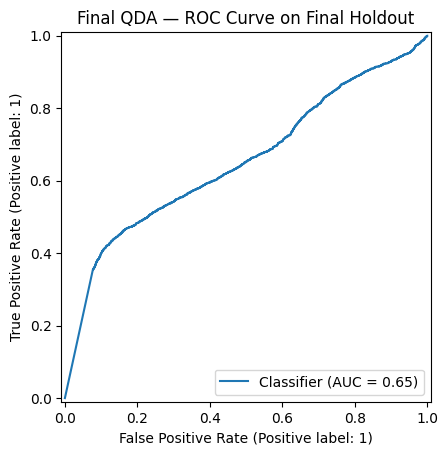

In [ ]:
# Final holdout ROC curve
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_holdout_binary,
    final_holdout_probabilities
)
plt.title("Final QDA — ROC Curve on Final Holdout")
plt.show()


### Final Holdout Precision-Recall Curve

The Precision-Recall curve was plotted to evaluate the final QDA model's performance across different classification thresholds.

The curve shows the trade-off between:

- **Precision** — the proportion of predicted subscribers who actually subscribed.
- **Recall** — the proportion of actual subscribers identified by the model.

The model's predicted subscription probabilities are used so that performance can be examined across different probability thresholds rather than only at the 0.5 threshold.

The Precision-Recall curve is particularly useful because the target variable is imbalanced, with subscribers representing a smaller proportion of the dataset.

The **Average Precision** metric provides a numerical summary of Precision-Recall performance across the different thresholds.

This curve is a standard model diagnostic. It is different from **Precision@500**, which evaluates the exact 500 highest-ranked records according to the bank's fixed campaign capacity.

For the campaign decision, Precision@500 and Lift@500 remain the most directly relevant measures.

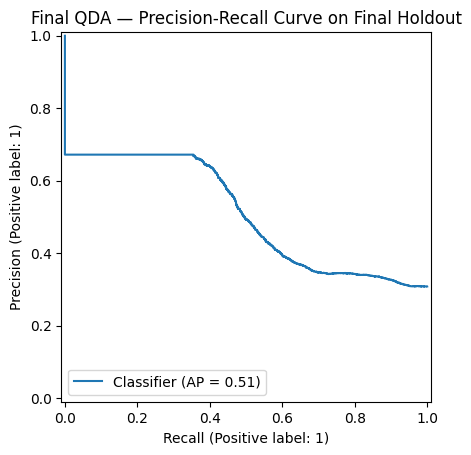

In [ ]:
# Final holdout Precision-Recall curve
PrecisionRecallDisplay.from_predictions(
    y_holdout_binary,
    final_holdout_probabilities
)
plt.title("Final QDA — Precision-Recall Curve on Final Holdout")
plt.show()


### Exporting the Final Top-500 Holdout Records

The final ranked holdout records were exported to a CSV file named:

`top_500_final_holdout.csv`

The first 500 records from the Final Holdout ranking were selected because the bank has a fixed campaign capacity of **500 calls**.

The exported table contains:

- `rank` — the model's ranking of the record based on predicted subscription probability.
- `original_row_index` — the original row position in the dataset, retained for traceability. This is not a customer identifier.
- `predicted_score` — the final QDA model's predicted probability of subscription.
- `historical_outcome` — the observed historical subscription outcome.
- the original Final Holdout feature variables used to describe the records.

The records are ordered from the highest predicted subscription probability to the lowest.

The historical outcome is included because this is an **offline evaluation using historical holdout records**. It would not be available for a genuinely new customer before a campaign.

The exported file therefore provides the required Top-500 ranked holdout demonstration while preserving the distinction between historical evaluation and a real future customer list.

In [ ]:
# Export the final Top-500 ranked holdout records.
# This is an offline historical demonstration, not a list of new customers.

final_top_500 = final_ranking.head(500).copy()
export_columns = [
    "rank",
    "original_row_index",
    "predicted_score",
    "historical_outcome"
] + [c for c in X_holdout.columns if c not in {"predicted_score", "historical_outcome"}]

final_top_500 = final_top_500[export_columns]
final_top_500.to_csv("top_500_final_holdout.csv", index=False)

print("Saved:", "top_500_final_holdout.csv")
print("Rows exported:", len(final_top_500))
display(final_top_500.head(10))


Saved: top_500_final_holdout.csv
Rows exported: 500


,rank,original_row_index,predicted_score,historical_outcome,age,job,marital,education,default,housing,...,month,day_of_week,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,1,41164,1.0,yes,54,admin.,married,professional.course,no,no,...,nov,tue,10,1,success,-1.1,94.767,-50.8,1.035,4963.6
1,2,37925,1.0,yes,60,retired,married,professional.course,no,yes,...,sep,thu,3,1,success,-3.4,92.379,-29.8,0.809,5017.5
2,3,37927,1.0,no,44,admin.,married,university.degree,no,yes,...,sep,thu,14,1,success,-3.4,92.379,-29.8,0.809,5017.5
3,4,37931,1.0,no,43,technician,married,high.school,no,yes,...,sep,thu,3,2,success,-3.4,92.379,-29.8,0.809,5017.5
4,5,37933,1.0,yes,26,student,single,unknown,no,yes,...,sep,thu,3,1,success,-3.4,92.379,-29.8,0.809,5017.5
5,6,37953,1.0,yes,39,blue-collar,married,basic.9y,no,yes,...,sep,fri,3,1,success,-3.4,92.379,-29.8,0.803,5017.5
6,7,41159,1.0,yes,35,technician,divorced,basic.4y,no,yes,...,nov,tue,9,4,success,-1.1,94.767,-50.8,1.035,4963.6
7,8,41162,1.0,no,60,blue-collar,married,basic.4y,no,yes,...,nov,tue,4,1,success,-1.1,94.767,-50.8,1.035,4963.6
8,9,39574,1.0,yes,48,blue-collar,married,basic.9y,no,yes,...,may,tue,3,3,success,-1.8,93.876,-40.0,0.668,5008.7
9,10,39575,1.0,yes,18,student,single,unknown,no,yes,...,may,tue,3,1,success,-1.8,93.876,-40.0,0.668,5008.7


### Final Campaign Summary

The final selected model was **Regularized Quadratic Discriminant Analysis (QDA)** with a `reg_param` value of **0.5**.

The model was selected using the chronological **Validation period**, with **Precision@500** as the main selection criterion because the bank has a fixed capacity of 500 calls.

After model selection, the final QDA model was refitted using the combined Development and Validation data. The **Final Holdout**, containing **8,237 records**, remained untouched until final evaluation.

The final model generated subscription probability scores for all Final Holdout records. These records were ranked from highest to lowest predicted probability, and the top 500 were selected to represent the bank's 500-call campaign capacity.

The final Top-500 results were:

- **Top-500 records:** 500
- **Historical subscribers in Top 500:** 328
- **Precision@500:** 65.6%
- **Final Holdout base rate:** 30.84%
- **Lift@500:** approximately 2.13×
- **Selected QDA regularization:** `reg_param = 0.5`

The Top-500 Precision of 65.6% is substantially higher than the overall Final Holdout subscription rate of 30.84%. The Lift@500 of approximately 2.13 indicates that the model's Top-500 ranking concentrated historical subscribers at a rate about 2.13 times the overall holdout rate.

ROC-AUC and Average Precision were also reported as standard model diagnostics.

The Final Holdout was not used for model selection. It was used only after the model-selection decision to perform final evaluation, generate probability scores, rank records and evaluate the Top-500 campaign scenario.

The Top-500 output is an **offline historical demonstration**, not a real list of new customers to contact.

In [ ]:
# Final campaign summary
print("Final selected model: Regularized QDA")
print("Selected reg_param:", selected_qda_reg)
print("Final holdout rows:", len(final_ranking))
print("Top-500 historical positives:", top_500_positives)
print("Precision@500:", round(precision_at_500, 4))
print("Lift@500:", round(lift_at_500, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("Average Precision:", round(average_precision, 4))
print("\nModel selection was based on validation Precision@500; the final holdout was used only for final evaluation and ranking.")


Final selected model: Regularized QDA
Selected reg_param: 0.5
Final holdout rows: 8237
Top-500 historical positives: 328
Precision@500: 0.656
Lift@500: 2.1274
ROC-AUC: 0.6539
Average Precision: 0.5056

Model selection was based on validation Precision@500; the final holdout was used only for final evaluation and ranking.


# Task 2 — Unsupervised Learning: Are There Meaningful Groups?

This section continues the same Bank Marketing project after Task 1. The supervised-learning notebook above is kept intact, and the unsupervised-learning workflow below is included as a separate section.

**Important:** The clustering solution is created without using `y`, current-call outcome information, or supervised-model predictions. The supervised results are introduced only after the clusters have been fixed.


# Task 2 — Unsupervised Learning: Customer Segmentation

In this task, we use unsupervised learning to investigate whether the bank's historical
contact records can be divided into meaningful groups.

Unlike supervised learning, we do not use the target variable `y` when creating the
clusters. The goal is to discover groups of records that are similar based on selected
client and past-campaign characteristics.

We will:

1. Define the unit of analysis.
2. Select appropriate clustering features.
3. Prepare categorical and numerical variables.
4. Apply K-Means clustering.
5. Compare different numbers of clusters.
6. Evaluate clusters using inertia and silhouette score.
7. Apply a second clustering method (Agglomerative Clustering).
8. Compare the clustering solutions.
9. Profile and visualise the resulting groups.
10. Later connect the fixed clusters to the supervised-learning results.

Important: clustering is exploratory. It does not prove that naturally distinct customer
types exist, and cluster labels themselves have no inherent meaning.

## 1. Import Required Libraries

We first import the Python libraries needed for clustering and evaluation.

- `numpy` is used for numerical data manipulation.
- `pandas` is used for loading and working with the dataset.
- `matplotlib` and `seaborn` are used for visualisation.
- `KMeans` provides the K-Means clustering algorithm.
- `silhouette_score` evaluates how well observations fit their assigned clusters.
- `StandardScaler` will later standardise numerical variables.
- `OneHotEncoder` will later convert categorical variables into numerical indicators.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## 2. Load the Bank Marketing Dataset

We load the `bank-additional-full.csv` dataset.

This dataset contains historical records of telephone marketing contacts made by a
Portuguese bank.

In [ ]:
df = pd.read_csv(
    "bank-additional-full.csv",
    sep=";"
)

print("Dataset shape:", df.shape)

Dataset shape: (41188, 21)


### Why do we use `sep=";"`?

The Bank Marketing dataset uses a semicolon (`;`) as its column separator rather than
the comma used by many CSV files.

Therefore, we explicitly tell pandas to use `;` when reading the file.

## 3. Initial Dataset Inspection

Before applying clustering, we need to understand what information is available.

We inspect:

- the first few records,
- column names,
- data types,
- and missing values.

This helps us decide which variables can reasonably be used to measure similarity
between records.

In [ ]:
print(df.head())
print(df.columns.tolist())
print(df.info())
print(df.isnull().sum())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

## 4. Unit of Analysis

The unit of analysis is the **historical contact record**.

Each row represents a contact between the bank and a client during a marketing campaign.

The dataset does not provide a dependable unique customer identifier. Therefore, we
should not assume that every row represents a different individual.

This means our clustering analysis identifies groups of **contact records with similar
characteristics**, rather than guaranteed unique customer segments.

This distinction is important when interpreting the results.

## 5. Selecting Features for Clustering

Clustering requires variables that describe the observations we want to compare.

However, we should not automatically include every column.

Some variables must be excluded because they would cause leakage or would not be
available at the point when the bank needs to decide whom to contact.

### Variables excluded

**`y`**
- This is the target variable from the supervised-learning task.
- Including it would allow the clustering algorithm to use the outcome we are trying
  to predict.
- Therefore, it must not be used when constructing clusters.

**`duration`**
- This records the duration of the current telephone call.
- It is only known after the current call has taken place.
- Therefore, it is not available when deciding whom to prioritise for a future call.

We will also avoid using any supervised-model predictions as clustering features.

The clustering should be constructed independently of the supervised model.

## 5. Selecting Features for Clustering

Clustering requires variables that describe the observations we want to compare.

However, we should not automatically include every column.

Some variables must be excluded because they would cause leakage or would not be
available at the point when the bank needs to decide whom to contact.

### Variables excluded

**`y`**
- This is the target variable from the supervised-learning task.
- Including it would allow the clustering algorithm to use the outcome we are trying
  to predict.
- Therefore, it must not be used when constructing clusters.

**`duration`**
- This records the duration of the current telephone call.
- It is only known after the current call has taken place.
- Therefore, it is not available when deciding whom to prioritise for a future call.

We will also avoid using any supervised-model predictions as clustering features.

The clustering should be constructed independently of the supervised model.

## 5. Selecting Features for Clustering

Clustering requires variables that describe the observations we want to compare.

However, we should not automatically include every column.

Some variables must be excluded because they would cause leakage or would not be
available at the point when the bank needs to decide whom to contact.

### Variables excluded

**`y`**
- This is the target variable from the supervised-learning task.
- Including it would allow the clustering algorithm to use the outcome we are trying
  to predict.
- Therefore, it must not be used when constructing clusters.

**`duration`**
- This records the duration of the current telephone call.
- It is only known after the current call has taken place.
- Therefore, it is not available when deciding whom to prioritise for a future call.

We will also avoid using any supervised-model predictions as clustering features.

The clustering should be constructed independently of the supervised model.

## 6. Candidate Clustering Features

We focus on variables that describe the client and their previous campaign history,
and that could reasonably be available when making a future contact decision.

Potential features include:

### Client characteristics
- `age`
- `job`
- `marital`
- `education`
- `default`
- `housing`
- `loan`

### Contact/history characteristics
- `contact`
- `month`
- `day_of_week`
- `campaign`
- `pdays`
- `previous`
- `poutcome`

The economic variables

- `emp.var.rate`
- `cons.price.idx`
- `cons.conf.idx`
- `euribor3m`
- `nr.employed`

require special consideration because they may primarily separate records from
different economic/time periods rather than represent differences between clients.

We will initially keep the clustering focused on client and campaign-history
characteristics and discuss the economic variables separately.

## 7. Create the Clustering Feature Dataset

We now create a separate dataframe containing only the variables selected for
clustering.

Keeping a separate feature dataframe makes the analysis easier to understand and
helps prevent accidentally including the target variable or post-contact information.

In [ ]:
cluster_features = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "campaign",
    "pdays",
    "previous",
    "poutcome"
]

X_cluster = df[cluster_features].copy()

X_cluster.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent


## 8. Separate Numerical and Categorical Features

Our selected variables contain two different types of data:

### Numerical variables

These contain numbers where arithmetic distances are meaningful.

Examples:
- `age`
- `campaign`
- `pdays`
- `previous`

### Categorical variables

These contain categories rather than meaningful numerical quantities.

Examples:
- `job`
- `marital`
- `education`
- `housing`

We need to represent these variables appropriately before clustering because K-Means
requires numerical input and calculates distances between observations.


## 9. Encoding Categorical Variables

Clustering algorithms such as K-Means require numerical input.

However, categorical variables should not simply be converted into arbitrary integers.

For example:

job:
- admin
- technician
- student

It would be incorrect to encode these as:

admin = 1
technician = 2
student = 3

because this would incorrectly suggest that:

student > technician > admin

and that the numerical differences between categories have meaning.

Instead, we use **one-hot encoding**.

For example:

job = admin

becomes:

admin  technician  student
  1        0          0

One-hot encoding therefore represents category membership without creating an artificial
ordering between categories.

In [ ]:
numeric_features = [
    "age",
    "campaign",
    "pdays",
    "previous"
]

categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome"
]

## 9. Encoding Categorical Variables

Clustering algorithms such as K-Means require numerical input.

However, categorical variables should not simply be converted into arbitrary integers.

For example:

job:
- admin
- technician
- student

It would be incorrect to encode these as:

admin = 1
technician = 2
student = 3

because this would incorrectly suggest that:

student > technician > admin

and that the numerical differences between categories have meaning.

Instead, we use **one-hot encoding**.

For example:

job = admin

becomes:

admin  technician  student
  1        0          0

One-hot encoding therefore represents category membership without creating an artificial
ordering between categories.

## 10. Scaling Numerical Variables

K-Means uses distances between observations.

Suppose one variable ranges from 18 to 95 while another ranges only from 0 to 10.

The variable with the larger numerical scale can have a greater influence on the
distance calculation.

To avoid this, we standardise the numerical variables.

Standardisation transforms a variable approximately so that:

- mean = 0
- standard deviation = 1

This puts numerical variables on a comparable scale before clustering.

## 11. Preprocess the Clustering Features

We now apply the two transformations discussed above:

1. Standardise numerical variables using `StandardScaler`.
2. Convert categorical variables into one-hot encoded variables using
   `OneHotEncoder`.

The resulting matrix contains only numerical values and can be supplied to
the clustering algorithms.


In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X_cluster)

print("Processed shape:", X_processed.shape)

Processed shape: (41188, 57)


`ColumnTransformer` allows us to apply different preprocessing steps to different
columns.

For numerical columns:
    StandardScaler()

For categorical columns:
    OneHotEncoder()

`fit_transform()` learns the required transformation from the data and then applies it.

The result is our numerical representation of the bank records for clustering.

## 12. K-Means Clustering

### What is K-Means?

K-Means divides observations into a specified number of clusters.

The algorithm:

1. Selects initial cluster centres.
2. Assigns each observation to the nearest centre.
3. Recalculates the centre of each cluster.
4. Repeats these steps until the solution converges.

The number of clusters is represented by **K**.

We start with K = 3 only as an initial candidate. This does not mean that we have
already concluded that three clusters are correct.

We will later compare different values of K using clustering diagnostics.

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_processed)

### `n_clusters=3`

Requests three clusters.

### `random_state=42`

Makes the experiment reproducible.

The number 42 has no special statistical meaning.

### `n_init=10`

Runs K-Means from multiple initial starting positions and keeps the best solution
according to the algorithm's objective.

### `fit_predict()`

Fits the K-Means model to the data and returns the cluster assignment for every record.

## 13. Cluster Sizes

Before looking at scores, we should check how many observations were assigned to each
cluster.

Very tiny clusters may indicate unusual or outlier-like groups rather than useful
segments.

In [ ]:
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

print(cluster_counts)

0    16191
1     1535
2    23462
Name: count, dtype: int64


In [ ]:
cluster_percentages = (
    pd.Series(kmeans_labels)
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print(cluster_percentages)

0    39.309993
1     3.726814
2    56.963193
Name: proportion, dtype: float64


## 14. Silhouette Score

The silhouette score measures how well observations fit within their assigned cluster
relative to other clusters.

Its approximate range is:

- close to +1 → observations are well matched to their own cluster
- around 0 → observations are near cluster boundaries
- below 0 → observations may be closer to another cluster

A higher score generally indicates better separation and cohesion.

However, silhouette score is not the only criterion we will use. We will also consider
cluster sizes, stability, and whether the clusters have meaningful and distinguishable
profiles.

In [ ]:
silhouette = silhouette_score(
    X_processed,
    kmeans_labels
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.10639345061741984


## 15. Inertia

K-Means also provides a measure called **inertia**.

Inertia measures the total squared distance between observations and the centroid of
their assigned cluster.

Lower inertia means that observations are more compact around their cluster centres.

However, inertia always tends to decrease as we increase the number of clusters.

Therefore, we do not simply choose the K with the lowest inertia.

Instead, we examine how much the inertia decreases as K increases. This produces the
basis of the Elbow Method.

In [ ]:
print("Inertia:", kmeans.inertia_)

Inertia: 309410.2351350544


## 16. Choosing Candidate Values of K — Elbow Method

We now test several possible numbers of clusters.

For each value of K, we record the K-Means inertia.

We then plot K against inertia.

The goal is to look for an approximate "elbow": a point after which adding more
clusters produces progressively smaller improvements in compactness.

The elbow is evidence for choosing candidate K values, not a guaranteed answer.

In [ ]:
inertias = []

k_values = range(2, 9)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_processed)

    inertias.append(model.inertia_)

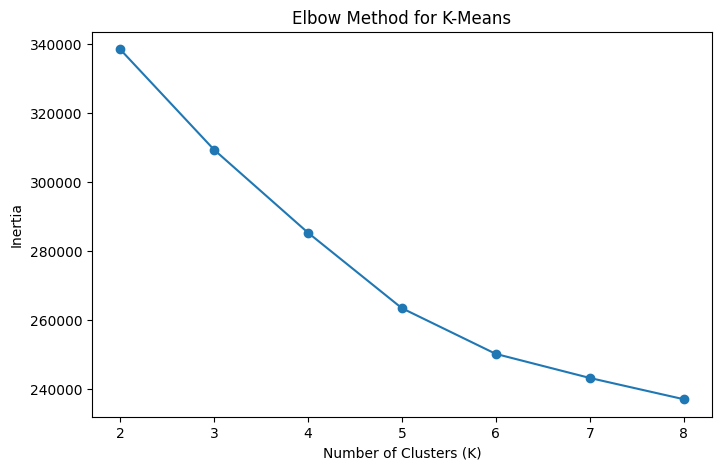

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.show()

## 17. Silhouette Score Across Different K

The Elbow Method looks at cluster compactness.

We also calculate the silhouette score for each candidate K.

This gives us another perspective: whether observations are relatively well separated
from other clusters.

We compare these results rather than relying on one metric alone.

In [ ]:
silhouette_scores = []

k_values = range(2, 9)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_processed)

    score = silhouette_score(
        X_processed,
        labels
    )

    silhouette_scores.append(score)

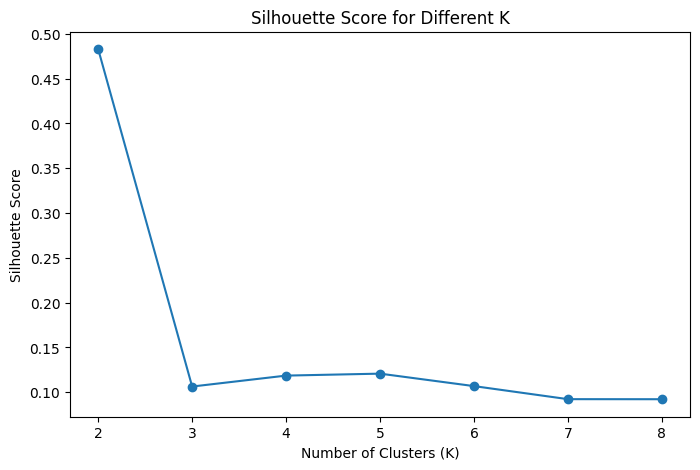

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K")

plt.show()

## Silhouette Score Summary

The table below summarises the silhouette score obtained for each candidate value of K.

The silhouette score measures how well observations fit within their assigned cluster
relative to other clusters.

Higher values generally indicate that observations are more cohesive within their own
cluster and better separated from other clusters.

The highest silhouette score can be used to identify candidate values of K, but it
should not be used as the only criterion. Cluster sizes, stability, and the
interpretability of cluster profiles will also be considered.

In [ ]:
silhouette_table = pd.DataFrame({
    "K": list(k_values),
    "Silhouette Score": silhouette_scores
})

silhouette_table

,K,Silhouette Score
0,2,0.482823
1,3,0.106393
2,4,0.118596
3,5,0.120783
4,6,0.106871
5,7,0.092305
6,8,0.092236


## 18. Selecting Candidate K Values

We now have two diagnostic views:

### Elbow Method
Shows how cluster compactness changes as K increases.

### Silhouette Score
Shows how well observations fit their own clusters relative to other clusters.

We should not automatically choose the K with the highest silhouette score.

Instead, we will identify a small number of plausible K values and investigate:

- silhouette score
- cluster sizes
- stability across random seeds
- cluster profiles
- whether very small or unusual groups appear
- interpretability of the resulting segments

The final K will therefore be selected using multiple pieces of evidence.

## Comparing K-Means Solutions

Silhouette score and inertia provide two different views of clustering quality.

- **Silhouette score:** measures how well observations fit within their own cluster compared with other clusters. Higher values are generally better.
- **Inertia:** measures how close observations are to their assigned cluster centroid. Lower values indicate more compact clusters.

We will consider both measures rather than selecting the number of clusters using only one metric.

In [ ]:
evaluation_table = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

evaluation_table

,K,Inertia,Silhouette Score
0,2,338505.912544,0.482823
1,3,309410.235135,0.106393
2,4,285369.113729,0.118596
3,5,263490.676199,0.120783
4,6,250251.498442,0.106871
5,7,243287.045741,0.092305
6,8,237127.967912,0.092236


## Inspecting Cluster Sizes

A clustering solution should not be evaluated using silhouette score alone.

We also inspect the number and percentage of observations in each cluster. Very small clusters may represent unusual observations, outliers, or overly specific patterns rather than useful segments.

In [ ]:
cluster_size_table = pd.DataFrame({
    "Cluster": cluster_counts.index,
    "Count": cluster_counts.values,
    "Percentage": cluster_percentages.values
})

cluster_size_table

,Cluster,Count,Percentage
0,0,16191,39.309993
1,1,1535,3.726814
2,2,23462,56.963193


## Examining the K=2 Cluster Sizes

K=2 produced the highest silhouette score among the tested values. Before considering it as a candidate clustering solution, we examine the size of each cluster.

This helps determine whether the solution produces substantial groups or whether one cluster contains only a very small number of observations.

In [ ]:
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_k2 = kmeans_2.fit_predict(X_processed)

k2_counts = pd.Series(labels_k2).value_counts().sort_index()

k2_percentages = (
    pd.Series(labels_k2)
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

k2_size_table = pd.DataFrame({
    "Cluster": k2_counts.index,
    "Count": k2_counts.values,
    "Percentage": k2_percentages.values
})

k2_size_table

,Cluster,Count,Percentage
0,0,39608,96.163931
1,1,1580,3.836069


K=2 produced the highest silhouette score among the tested values, but it also produced a highly imbalanced solution. Therefore, the two clusters need to be profiled to determine whether the smaller group represents a meaningful segment or an artifact of the feature representation.

## Profiling the K=2 Clusters

After evaluating the clustering metrics, we examine the characteristics of each cluster.

We first compare numerical features using their original values. This is important because the clustering was performed on transformed data, but the original values are easier to interpret from a business perspective.

We do not use the target variable `y` when creating these profiles.

In [ ]:
profile_numeric = df.copy()

profile_numeric["Cluster"] = labels_k2

numeric_profile = (
    profile_numeric
    .groupby("Cluster")[numeric_features]
    .mean()
    .round(2)
)

numeric_profile


,age,campaign,pdays,previous
Cluster,,,,
0,39.95,2.60,999.00,0.11
1,41.76,1.84,46.87,1.73


| Feature  | Cluster 0 | Cluster 1 | What it suggests                                    |
| -------- | --------: | --------: | --------------------------------------------------- |
| Age      |     39.95 |     41.76 | Age is quite similar                                |
| Campaign |      2.60 |      1.84 | Cluster 0 has more contacts in the current campaign |
| `pdays`  |    999.00 |     46.87 | **Very large difference**                           |
| Previous |      0.11 |      1.73 | **Large difference**                                |


## Profiling Categorical Features

We compare the distribution of categorical features across the clusters.

Because the clusters have different sizes, we use percentages rather than raw counts. This allows us to compare the composition of each cluster fairly.

We examine variables such as job, education, housing, loan, contact method, and previous campaign outcome.

In [ ]:
categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome"
]

profile_categorical = df.copy()
profile_categorical["Cluster"] = labels_k2

In [ ]:
job_profile = pd.crosstab(
    profile_categorical["Cluster"],
    profile_categorical["job"],
    normalize="index"
) * 100

job_profile.round(2)

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
Cluster,,,,,,,,,,,,
0,25.07,23.03,3.61,2.57,7.10,3.88,3.50,9.82,1.83,16.41,2.40,0.78
1,31.14,8.29,1.65,2.66,7.15,11.52,2.09,5.06,9.62,15.44,4.11,1.27


In [ ]:
categorical_profiles = {}

for feature in categorical_features:
    table = pd.crosstab(
        profile_categorical["Cluster"],
        profile_categorical[feature],
        normalize="index"
    ) * 100

    categorical_profiles[feature] = table.round(2)

for feature, table in categorical_profiles.items():
    print(f"\n--- {feature} ---")
    display(table)


--- job ---


job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
Cluster,,,,,,,,,,,,
0,25.07,23.03,3.61,2.57,7.10,3.88,3.50,9.82,1.83,16.41,2.40,0.78
1,31.14,8.29,1.65,2.66,7.15,11.52,2.09,5.06,9.62,15.44,4.11,1.27



--- marital ---


marital,divorced,married,single,unknown
Cluster,,,,
0,11.27,60.86,27.68,0.19
1,9.30,52.15,38.23,0.32



--- education ---


...

month,apr,aug,dec,jul,jun,mar,may,nov,oct,sep
Cluster,,,,,,,,,,
0,6.34,14.97,0.34,17.81,13.03,1.14,34.12,9.85,1.39,1.00
1,7.53,15.63,2.97,7.59,10.06,5.95,16.20,12.59,10.57,10.89



--- day_of_week ---


day_of_week,fri,mon,thu,tue,wed
Cluster,,,,,
0,19.10,20.67,20.88,19.58,19.76
1,16.52,20.63,22.34,21.14,19.37



--- poutcome ---


poutcome,failure,nonexistent,success
Cluster,,,
0,10.21,89.79,0.0
1,13.10,0.00,86.9


## Checking K-Means Stability

K-Means can produce slightly different results depending on its initialization.

To assess stability, we run the K=2 solution using several different random seeds and compare the resulting cluster sizes and silhouette scores.

A stable solution should produce broadly similar results across different seeds. Cluster numbers themselves may be swapped between runs, so we focus on the sizes and quality of the solutions rather than the numerical cluster labels.

## Reproducible Sample for Clustering Stability

The full dataset contains over 41,000 records, making repeated silhouette calculations computationally expensive.

For stability evaluation, we use a reproducible sample of 5,000 records. The same sample is used across all random seeds so that differences between runs are caused by K-Means initialization rather than by different observations.

The sample size and random seed are documented to make the analysis reproducible.

In [ ]:
sample_df = df.sample(
    n=5000,
    random_state=42
)

X_sample = sample_df[cluster_features].copy()

print("Sample shape:", X_sample.shape)


X_sample_processed = preprocessor.fit_transform(X_sample)

print("Processed sample shape:", X_sample_processed.shape)

Sample shape: (5000, 14)
Processed sample shape: (5000, 56)


In [ ]:
stability_results = []

seeds = [0, 10, 42, 100, 2026]

for seed in seeds:
    model = KMeans(
        n_clusters=2,
        random_state=seed,
        n_init=10
    )

    labels = model.fit_predict(X_sample_processed)

    score = silhouette_score(
        X_sample_processed,
        labels
    )

    cluster_sizes = pd.Series(labels).value_counts().sort_index()

    stability_results.append({
        "Seed": seed,
        "Silhouette Score": score,
        "Cluster 0 Count": cluster_sizes.get(0, 0),
        "Cluster 1 Count": cluster_sizes.get(1, 0)
    })

stability_table = pd.DataFrame(stability_results)

stability_table.round(4)


,Seed,Silhouette Score,Cluster 0 Count,Cluster 1 Count
0,0,0.4801,4799,201
1,10,0.4801,201,4799
2,42,0.4801,4799,201
3,100,0.2825,655,4345
4,2026,0.4801,4799,201


## Agglomerative Clustering

Agglomerative Clustering is a hierarchical clustering method.

Unlike K-Means, which assigns observations to cluster centres,
Agglomerative Clustering starts with each observation as its own cluster
and repeatedly merges the most similar clusters.

We use it as a second clustering approach to check whether a different
clustering method produces a similar structure to K-Means.

Because the dataset contains 41,188 records, we use the documented
5,000-record sample for this method to keep computation practical.


In [ ]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

agglo_labels = agglo.fit_predict(X_sample_processed.toarray())

print("Agglomerative clustering completed.")

Agglomerative clustering completed.


In [ ]:
agglo_counts = pd.Series(agglo_labels).value_counts().sort_index()

print("Agglomerative cluster sizes:")
print(agglo_counts)

Agglomerative cluster sizes:
0    4802
1     198
Name: count, dtype: int64


In [ ]:
agglo_silhouette = silhouette_score(
    X_sample_processed,
    agglo_labels
)

print("Agglomerative Silhouette Score:", agglo_silhouette)

Agglomerative Silhouette Score: 0.48015572168804393


## Comparing K-Means and Agglomerative Clustering

Both clustering methods were evaluated on the same reproducible sample of
5,000 records.

K-Means produced clusters of 4,799 and 201 records, with a silhouette score
of approximately 0.4801.

Agglomerative Clustering produced clusters of 4,802 and 198 records, with a
silhouette score of approximately 0.4802.

The very similar cluster sizes and silhouette scores indicate that the two
different clustering approaches identify a very similar structure in the
data.

This increases confidence that the observed separation is not specific to
one clustering algorithm.

## Final Clustering Solution

Based on the clustering experiments, we use K-Means with K=2 as the final
clustering solution.

K=2 produced the strongest silhouette score among the tested K values,
while the alternative Agglomerative method produced a very similar
two-group structure.

Therefore, the two clusters are fixed at this stage.

No target variable (`y`) or supervised-model prediction is used to create
these clusters.

In [ ]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(X_processed)

df["cluster"] = final_labels

print(df["cluster"].value_counts().sort_index())

cluster
0    39608
1     1580
Name: count, dtype: int64


## Additional check: duplicate and outlier-like records

The assignment asks us to consider whether very small, near-duplicate, or outlier-like groups could be driving the clustering.

We first count exact duplicate rows in the clustering feature representation. We then examine each record’s distance to its nearest K-Means centroid. Records in the furthest 1% are treated as **outlier-like for inspection only**; this does not create another cluster or change the final K=2 solution.

This is a descriptive check rather than a claim that every flagged record is a true statistical outlier.

In [ ]:
# Exact duplicate check in the original clustering feature representation
duplicate_count = X_cluster.duplicated().sum()
duplicate_percentage = duplicate_count / len(X_cluster) * 100

print("Exact duplicate clustering records:", duplicate_count)
print("Percentage of clustering records:", round(duplicate_percentage, 2), "%")


Exact duplicate clustering records: 2744
Percentage of clustering records: 6.66 %


In [ ]:
# Outlier-like records: distance to the nearest final K-Means centroid
nearest_centroid_distance = final_kmeans.transform(X_processed).min(axis=1)
outlier_threshold = np.quantile(nearest_centroid_distance, 0.99)
outlier_mask = nearest_centroid_distance >= outlier_threshold

outlier_summary = pd.DataFrame({
    "cluster": final_labels[outlier_mask],
    "distance_to_centroid": nearest_centroid_distance[outlier_mask]
})

print("Outlier-like records (furthest 1%):", outlier_mask.sum())
print("Distance threshold:", round(outlier_threshold, 3))
print("Outlier-like records by cluster:")
print(outlier_summary["cluster"].value_counts().sort_index())


Outlier-like records (furthest 1%): 412
Distance threshold: 5.678
Outlier-like records by cluster:
cluster
0    318
1     94
Name: count, dtype: int64


**Interpretation:** The final K=2 solution does not create a separate tiny outlier cluster. The outlier-like check is used only to make sure that unusual records are not being mistaken for a meaningful additional segment. Exact duplicate records are also not automatically interpreted as unique customers, which is consistent with the dataset’s lack of a dependable customer identifier.

## PCA Visualization

The processed clustering data contains many dimensions because categorical
variables were converted using one-hot encoding.

Principal Component Analysis (PCA) is used to reduce this representation
to two dimensions so that the clustering structure can be visualized.

The PCA plot is used for visualization only. Separation in two PCA
dimensions does not prove that the clusters are fully separated in the
original feature space.


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_processed.toarray())

print("PCA shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)

PCA shape: (41188, 2)
Explained variance ratio: [0.18180958 0.11624126]


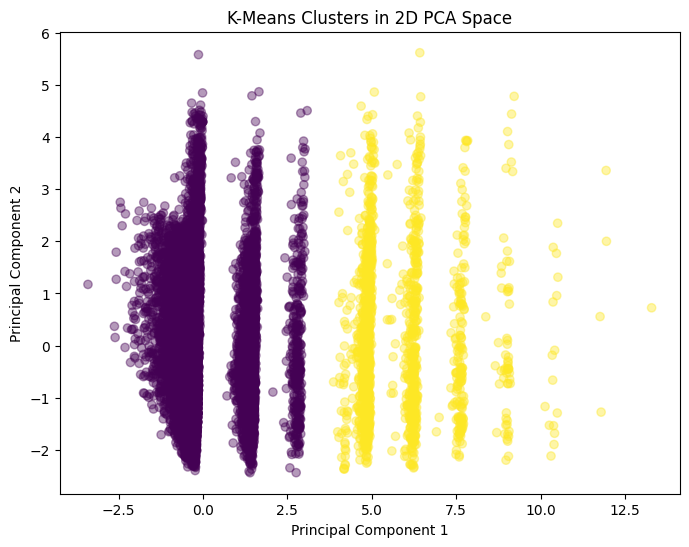

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=final_labels,
    alpha=0.4
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters in 2D PCA Space")

plt.show()

## Final Cluster Profiles

After fixing the clustering solution, we profile the clusters using the
original variables.

Numeric variables are summarized using their mean values. This helps
describe how the groups differ in terms of age and previous campaign
history.

The target variable `y` is not used to create or define the clusters.

In [ ]:
numeric_profile = (
    df.groupby("cluster")[numeric_features]
      .mean()
      .round(2)
)

numeric_profile

,age,campaign,pdays,previous
cluster,,,,
0,39.95,2.60,999.00,0.11
1,41.76,1.84,46.87,1.73


In [ ]:
cluster_profile = (
    df["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

cluster_profile["Percentage"] = (
    cluster_profile["Count"] / len(df) * 100
).round(2)

cluster_profile

,Count,Percentage
cluster,,
0,39608,96.16
1,1580,3.84


## Connecting the fixed clusters to Task 1

The clusters are now fixed. Only at this point do we introduce the historical target `y` and the final supervised-model scores.

The Task 1 notebook used a chronological final holdout. We reuse its original row indices so that each held-out record can be matched to the fixed Task 2 cluster. This does **not** change the clustering.

The comparisons below are descriptive associations in historical data. They do not prove that assigning a future customer to a cluster would cause a different campaign response.

In [ ]:
# Align the Task 1 final holdout with the fixed Task 2 clusters
holdout_indices = X_holdout.index

holdout_cluster = pd.DataFrame({
    "original_row_index": holdout_indices,
    "cluster": df.loc[holdout_indices, "cluster"].values,
    "actual_y": y_holdout.values,
    "predicted_score": final_holdout_probabilities
})

print("Final holdout records aligned:", len(holdout_cluster))
display(holdout_cluster.head())


Final holdout records aligned: 8237


,original_row_index,cluster,actual_y,predicted_score
0,32951,0,no,0.089122
1,32952,0,no,0.047791
2,32953,0,no,0.303653
3,32954,0,no,0.097547
4,32955,0,no,0.247980


## Held-out subscription rate by cluster

We now compare historical subscription rates across the **fixed clusters** on the Task 1 final holdout. The target was not used to create the clusters; it is introduced only for this post-clustering evaluation.

In [ ]:
cluster_subscription = (
    holdout_cluster
    .groupby("cluster")
    .agg(
        Records=("actual_y", "size"),
        Subscriptions=("actual_y", lambda x: (x == "yes").sum())
    )
)

cluster_subscription["Subscription Rate (%)"] = (
    cluster_subscription["Subscriptions"] /
    cluster_subscription["Records"] * 100
).round(2)

cluster_subscription


,Records,Subscriptions,Subscription Rate (%)
cluster,,,
0,6832,1627,23.81
1,1405,913,64.98


## Held-out Task 1 score distribution by cluster

Next we compare the final QDA model’s predicted subscription scores across the fixed clusters. Higher scores mean the final model ranked those records as more likely to subscribe.

This is a descriptive comparison: the QDA model was trained and selected independently of the clustering solution.

In [ ]:
cluster_score_summary = (
    holdout_cluster
    .groupby("cluster")["predicted_score"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(4)
)

cluster_score_summary


,count,mean,median,std,min,max
cluster,,,,,,
0,6832,0.2260,0.2189,0.1555,0.0052,0.9362
1,1405,0.9664,1.0000,0.1636,0.0119,1.0000


## Cluster representation in the 500-call recommendation

The final Task 1 campaign rule remains the 500 highest QDA scores. We now simply add the fixed cluster label to those 500 records to see whether one cluster is disproportionately represented.

This does not replace the model ranking with clustering. The clusters are used as an additional descriptive lens on the existing recommendation.

In [ ]:
top_500_cluster = final_top_500.copy()
top_500_cluster["cluster"] = df.loc[
    top_500_cluster["original_row_index"], "cluster"
].values

top_500_cluster_summary = (
    top_500_cluster["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("Top-500 Records")
)
top_500_cluster_summary["Percentage of Top-500 (%)"] = (
    top_500_cluster_summary["Top-500 Records"] / 500 * 100
).round(2)

top_500_cluster_summary


,Top-500 Records,Percentage of Top-500 (%)
cluster,,
1,500,100.0


## Does segmentation change the 500-call recommendation?

The 500-call recommendation remains the records ranked highest by the final QDA model. Cluster membership does not replace the model score and is not used to re-rank the 500 records.

Use the three tables above to judge practical value: if the clusters have clearly different held-out subscription rates and/or score distributions, segmentation may provide useful campaign profiling. If the differences are small, or if the clusters mainly reflect previous-contact history without adding information beyond the QDA ranking, then segmentation adds limited practical value.

Either conclusion is acceptable when supported by the evidence. Importantly, these historical associations do not constitute a tested campaign intervention.

## Task 2 final requirement checklist

- **Unit:** historical contact records, not guaranteed unique individual clients.
- **Feature rationale:** compact client and campaign-history variables; economic indicators are discussed separately because they can primarily encode time/economic regime.
- **Similarity representation:** categorical variables are one-hot encoded and numerical variables standardized; this representation is used with Euclidean-style distance for K-Means.
- **Leakage control:** `y`, current-call outcome information, and supervised-model predictions are excluded from clustering features.
- **Method comparison:** K-Means and Agglomerative Clustering are compared on a documented reproducible 5,000-record sample.
- **Diagnostics:** inertia, silhouette, cluster sizes, stability across seeds, profiles, duplicate checks, and an outlier-like inspection are included.
- **Visualisation:** labelled 2D PCA projection is included, with the limitation that PC1 + PC2 explain only about 29.8% of total variance.
- **Profiles:** cluster sizes and numerical/categorical characteristics are reported.
- **Task 1 connection:** only after clusters are fixed, held-out subscription rates, QDA score distributions, and Top-500 cluster representation are compared.
- **Business verdict:** the 500-call ranking remains the QDA ranking; clustering is an additional segmentation/profile lens rather than a replacement decision rule.